# FinsightAI — RAGAS Evaluation Results Analysis

This notebook analyses every `.xlsx` file in this `results/` directory from:

- `tests/rag/test_ragas_evaluation.py` (pytest), and
- `tests/rag/test_rag.ipynb` (interactive unittest runs).

It classifies each file, keeps the **newest** run per logical name (by file modification time), and plots retrieval metrics **separately for each embedding backend** (Chroma default vs OpenAI `text-embedding-3-small`).

**Retrieval outputs (dual embeddings)**

| Kind | Filename stem (before `_YYYYMMDD` or `_YYYYMMDD-HHMMSS`) |
|---|---|
| Similarity | `similarity_chroma`, `similarity_openai`, or legacy `similarity_scores` |
| SEC hit rate | `hit_rate_sec_filings_chroma`, `hit_rate_sec_filings_openai`, `hit_rate_sec_chroma`, `hit_rate_sec_openai`, or legacy `sec_filings_hit_rate` |
| News hit rate | `hit_rate_news_chroma`, `hit_rate_news_openai`, or legacy `news_hit_rate` |

**RAGAS / tool outputs**

| Test | Output prefix |
|---|---|
| Faithfulness | `ragas_faithfulness_*` |
| Answer relevancy | `ragas_relevancy_*` |
| Tool call accuracy | `tool_call_accuracy_*`, `tool_accuracy_*` (pytest), or `ragas_tool_accuracy_*` (notebook) |
| Response time | `response_time_*` |

In [ ]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# ── UTS colour palette ─────────────────────────────────────────────────────────
UTS = {
    "black":  "#000000",
    "white":  "#FFFFFF",
    "pink":   "#E40046",
    "blue":   "#008BB0",
    "green":  "#A4C53C",
    "orange": "#F39200",
    "purple": "#6E298D",
    "teal":   "#009085",
    "amber":  "#FAC000",
    "red":    "#E31B23",
    "grey":   "#58595B",
}

# Semantic role mappings used throughout all charts
C_PASS      = UTS["green"]   # bars / markers that meet or exceed the threshold
C_FAIL      = UTS["red"]     # bars / markers that fall below the threshold
C_THRESHOLD = UTS["blue"]    # threshold reference line
C_MEAN      = UTS["orange"]  # mean reference line
C_PRIMARY   = UTS["blue"]    # default single-series bar / scatter colour
C_SECONDARY = UTS["teal"]    # second series colour
C_ACCENT    = UTS["purple"]  # accent / highlight colour

# Ordered list for multi-category charts (golden overview, collections, tickers)
UTS_CYCLE = [
    UTS["blue"], UTS["teal"], UTS["purple"], UTS["orange"],
    UTS["amber"], UTS["pink"], UTS["green"], UTS["grey"],
]

# ── Matplotlib / Seaborn global style ─────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi":        150,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.titlesize":  14,
    "figure.titleweight": "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

RESULTS_DIR = Path(".")  # notebook lives inside results/
GOLDEN_PATH = Path("..") / "golden_dataset.json"

# ── Quality thresholds (mirror test file) ─────────────────────────────────────
THRESHOLDS = {
    "faithfulness":    0.40,
    "answer_relevancy": 0.60,
    "tool_accuracy":   0.80,
    "hit_rate":        0.70,
    "similarity":      0.50,
}

print("Setup complete.")

Setup complete.


## 1  Load golden dataset

In [2]:
with open(GOLDEN_PATH) as f:
    golden_raw = json.load(f)

golden = pd.DataFrame(golden_raw)
golden["expected_collection"] = golden["expected_collection"].fillna("none")

print(f"Golden dataset: {len(golden)} cases")
display(golden[["id", "question", "expected_tool", "expected_collection", "ticker"]].head(8))

Golden dataset: 52 cases


,id,question,expected_tool,expected_collection,ticker
0,gd-001,What are Amazon's main risk factors according ...,vector_store,sec_filings,AMZN
1,gd-002,What was Apple's total revenue in fiscal year ...,get_fundamentals,none,AAPL
2,gd-003,What are the key growth strategies mentioned i...,vector_store,sec_filings,MSFT
3,gd-004,What is NVIDIA's current market capitalisation...,get_company_financials,none,NVDA
4,gd-005,What recent news sentiment surrounds Tesla?,vector_store,news,TSLA
5,gd-006,Show me Apple's historical stock price for the...,get_price_history,none,AAPL
6,gd-007,What capital expenditures did Amazon report in...,vector_store,sec_filings,AMZN
7,gd-008,What is my current portfolio balance?,get_portfolio,none,NaN


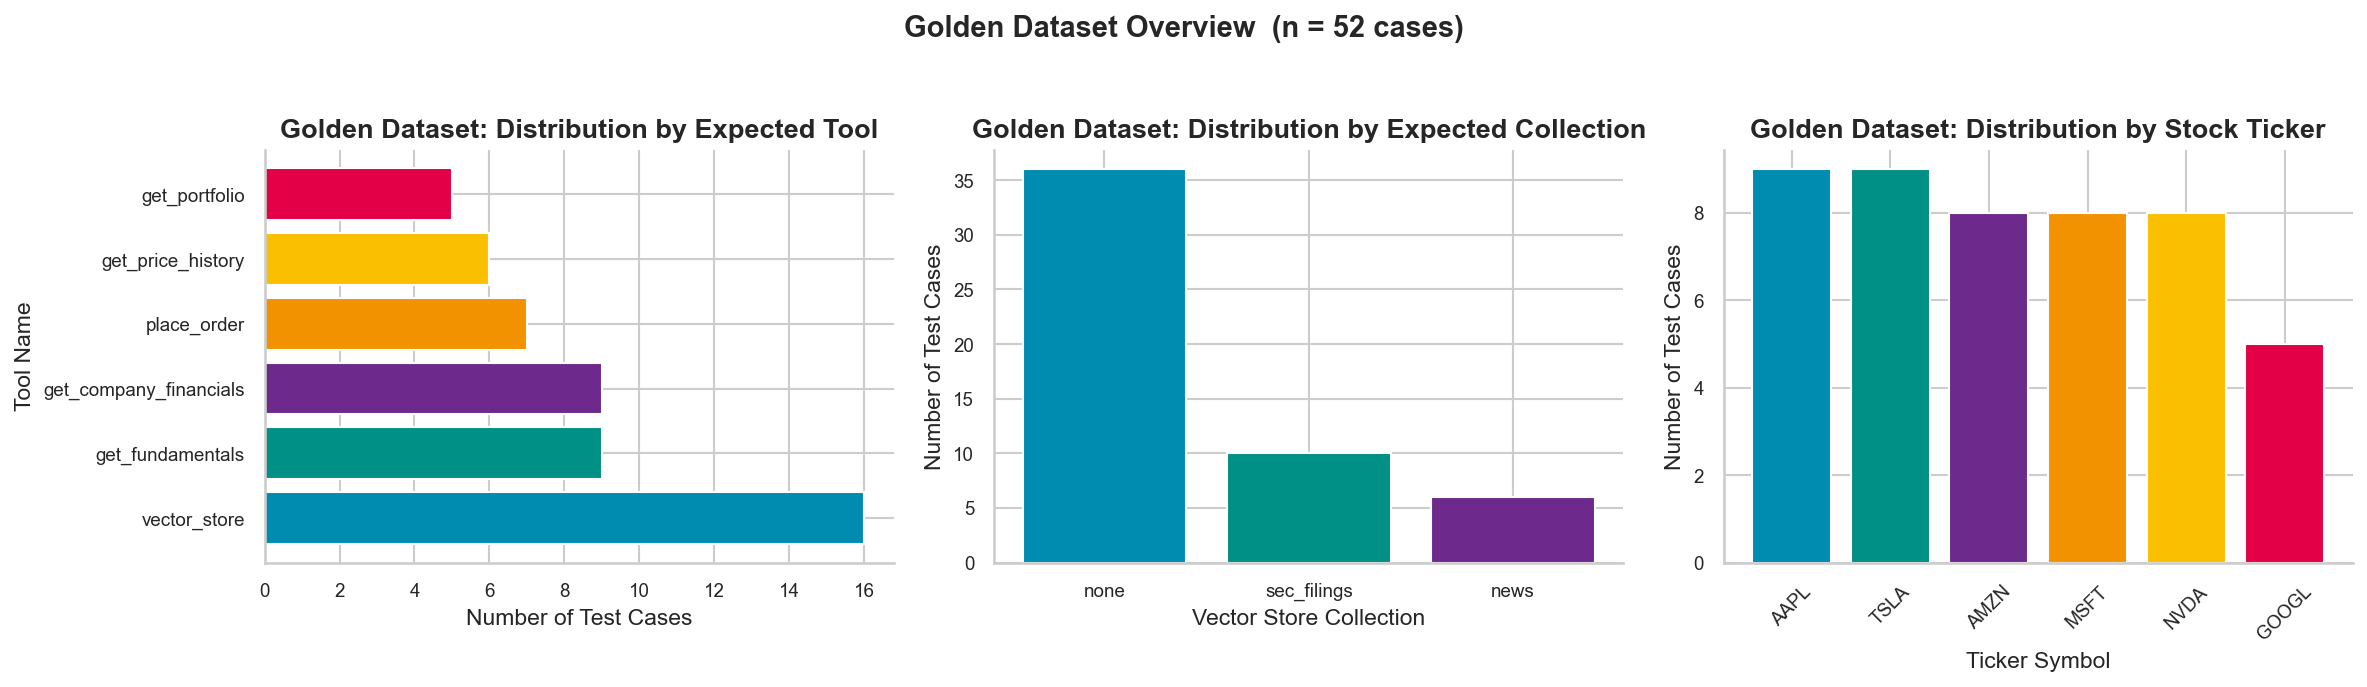

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

tool_counts = golden["expected_tool"].value_counts()
axes[0].barh(tool_counts.index, tool_counts.values,
             color=UTS_CYCLE[:len(tool_counts)])
axes[0].set_title("Golden Dataset: Distribution by Expected Tool")
axes[0].set_xlabel("Number of Test Cases")
axes[0].set_ylabel("Tool Name")
for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)

coll_counts = golden["expected_collection"].value_counts()
axes[1].bar(coll_counts.index, coll_counts.values,
            color=UTS_CYCLE[:len(coll_counts)])
axes[1].set_title("Golden Dataset: Distribution by Expected Collection")
axes[1].set_xlabel("Vector Store Collection")
axes[1].set_ylabel("Number of Test Cases")
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

ticker_counts = golden["ticker"].value_counts()
axes[2].bar(ticker_counts.index, ticker_counts.values,
            color=UTS_CYCLE[:len(ticker_counts)])
axes[2].set_title("Golden Dataset: Distribution by Stock Ticker")
axes[2].set_xlabel("Ticker Symbol")
axes[2].set_ylabel("Number of Test Cases")
axes[2].tick_params(axis="x", rotation=45)
for spine in ["top", "right"]:
    axes[2].spines[spine].set_visible(False)

fig.suptitle(f"Golden Dataset Overview  (n = {len(golden)} cases)", y=1.02)
plt.tight_layout()
plt.savefig("golden_dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 2  Discover and load result files

In [ ]:
def strip_date_suffix(stem: str) -> str:
    """Remove trailing _YYYYMMDD or _YYYYMMDD-HHMMSS from result filenames."""
    return re.sub(r"_\d{8}(-\d{6})?$", "", stem)


FILE_META = {
    "similarity_scores": ("Retrieval – Similarity (legacy)", "similarity"),
    "similarity_chroma": ("Retrieval – Similarity (Chroma embeddings)", "similarity"),
    "similarity_openai": ("Retrieval – Similarity (OpenAI embeddings)", "similarity"),
    "sec_filings_hit_rate": ("Retrieval – SEC hit rate (legacy)", "hit"),
    "news_hit_rate": ("Retrieval – News hit rate (legacy)", "hit"),
    "hit_rate_sec_filings_chroma": ("Retrieval – SEC hit rate (Chroma)", "hit"),
    "hit_rate_sec_filings_openai": ("Retrieval – SEC hit rate (OpenAI)", "hit"),
    "hit_rate_sec_chroma": ("Retrieval – SEC hit rate (Chroma, pytest alias)", "hit"),
    "hit_rate_sec_openai": ("Retrieval – SEC hit rate (OpenAI, pytest alias)", "hit"),
    "hit_rate_news_chroma": ("Retrieval – News hit rate (Chroma)", "hit"),
    "hit_rate_news_openai": ("Retrieval – News hit rate (OpenAI)", "hit"),
    "ragas_faithfulness": ("RAGAS – Faithfulness", "faithfulness"),
    "ragas_relevancy": ("RAGAS – Answer Relevancy", "answer_relevancy"),
    "tool_call_accuracy": ("Tool Call Accuracy", "tool_call_accuracy"),
    "tool_accuracy": ("Tool Call Accuracy", "tool_call_accuracy"),
    "ragas_tool_accuracy": ("Tool Call Accuracy", "tool_call_accuracy"),
    "response_time": ("Response Time", "response_time_s"),
}

# Aliases: when multiple keys map to the same logical test, keep the canonical name.
KEY_ALIASES: dict[str, str] = {
    "tool_accuracy": "tool_call_accuracy",
    "ragas_tool_accuracy": "tool_call_accuracy",
}

loaded: dict[str, pd.DataFrame] = {}
_best_mtime: dict[str, float] = {}

for xlsx in RESULTS_DIR.glob("*.xlsx"):
    key = strip_date_suffix(xlsx.stem)
    if key not in FILE_META:
        print(f"  [skip]  {xlsx.name}  (unknown stem '{key}')")
        continue
    canonical = KEY_ALIASES.get(key, key)
    mtime = xlsx.stat().st_mtime
    if canonical in loaded and mtime <= _best_mtime[canonical]:
        continue
    df = pd.read_excel(xlsx)
    loaded[canonical] = df
    _best_mtime[canonical] = mtime
    print(f"  Loaded  {xlsx.name:55s}  → {canonical}  [{len(df)} rows, {df.columns.tolist()}]")

if not loaded:
    print("No recognised result files — run tests or the RAG notebook first.")
else:
    print(f"\nTotal logical result groups loaded: {len(loaded)}")


def similarity_result_iter():
    for label, key in [
        ("Chroma", "similarity_chroma"),
        ("OpenAI", "similarity_openai"),
        ("Legacy", "similarity_scores"),
    ]:
        if key in loaded:
            yield label, key


def hit_rate_result_iter():
    specs = [
        ("SEC – Chroma", "hit_rate_sec_filings_chroma"),
        ("SEC – Chroma (pytest)", "hit_rate_sec_chroma"),
        ("SEC – OpenAI", "hit_rate_sec_filings_openai"),
        ("SEC – OpenAI (pytest)", "hit_rate_sec_openai"),
        ("News – Chroma", "hit_rate_news_chroma"),
        ("News – OpenAI", "hit_rate_news_openai"),
        ("SEC – Legacy", "sec_filings_hit_rate"),
        ("News – Legacy", "news_hit_rate"),
    ]
    for disp, key in specs:
        if key in loaded:
            yield disp, key


  Loaded  ragas_tool_accuracy_20260428.xlsx                        → tool_call_accuracy  [20 rows, ['id', 'question', 'expected_tool', 'ai_tools', 'tool_call_accuracy', 'passed']]
  Loaded  hit_rate_sec_filings_chroma_20260427.xlsx                → hit_rate_sec_filings_chroma  [10 rows, ['id', 'question', 'hit']]
  Loaded  hit_rate_news_chroma_20260427.xlsx                       → hit_rate_news_chroma  [6 rows, ['id', 'question', 'hit']]
  Loaded  ragas_faithfulness_20260427.xlsx                         → ragas_faithfulness  [16 rows, ['question', 'answer', 'contexts', 'ground_truth', 'faithfulness']]
  Loaded  similarity_openai_20260427.xlsx                          → similarity_openai  [16 rows, ['id', 'similarity', 'passed']]
  Loaded  ragas_relevancy_20260428.xlsx                            → ragas_relevancy  [20 rows, ['question', 'answer', 'ground_truth', 'answer_relevancy']]
  Loaded  similarity_chroma_20260427.xlsx                          → similarity_chroma  [16 rows, ['id', 

## 3  Similarity Scores Analysis

In [5]:
_sim_any = False
_threshold = THRESHOLDS["similarity"]

for emb_label, skey in similarity_result_iter():
    _sim_any = True
    sim = loaded[skey].copy()
    sim = sim.merge(golden[["id", "question", "expected_collection", "ticker"]], on="id", how="left")
    pass_rate = sim["passed"].mean()
    avg_sim = sim["similarity"].mean()
    print(f"\n=== Similarity — {emb_label} (`{skey}`) ===")
    print(f"Threshold  : {_threshold}")
    print(f"Pass rate  : {pass_rate:.1%}  ({sim['passed'].sum()}/{len(sim)} cases)")
    print(f"Avg cosine : {avg_sim:.4f}")
    display(sim[["id", "similarity", "passed", "expected_collection", "ticker"]].sort_values("similarity", ascending=False))

if not _sim_any:
    print("No similarity result files found (similarity_chroma / similarity_openai / similarity_scores) — skipping.")



=== Similarity — Chroma (`similarity_chroma`) ===
Threshold  : 0.5
Pass rate  : 87.5%  (14/16 cases)
Avg cosine : 0.6170


,id,similarity,passed,expected_collection,ticker
14,gd-041,0.740126,True,news,AMZN
9,gd-036,0.686554,True,sec_filings,NVDA
12,gd-039,0.680709,True,news,NVDA
0,gd-001,0.651748,True,sec_filings,AMZN
13,gd-040,0.644886,True,news,MSFT
2,gd-005,0.635806,True,news,TSLA
8,gd-035,0.632707,True,sec_filings,TSLA
10,gd-037,0.627336,True,sec_filings,AAPL
7,gd-034,0.623197,True,sec_filings,AMZN
4,gd-009,0.622295,True,sec_filings,GOOGL



=== Similarity — OpenAI (`similarity_openai`) ===
Threshold  : 0.5
Pass rate  : 100.0%  (16/16 cases)
Avg cosine : 0.6186


,id,similarity,passed,expected_collection,ticker
13,gd-040,0.707778,True,news,MSFT
9,gd-036,0.663615,True,sec_filings,NVDA
2,gd-005,0.636610,True,news,TSLA
6,gd-012,0.635938,True,sec_filings,NVDA
4,gd-009,0.635724,True,sec_filings,GOOGL
0,gd-001,0.632294,True,sec_filings,AMZN
3,gd-007,0.620257,True,sec_filings,AMZN
14,gd-041,0.619663,True,news,AMZN
1,gd-003,0.615321,True,sec_filings,MSFT
7,gd-034,0.615230,True,sec_filings,AMZN


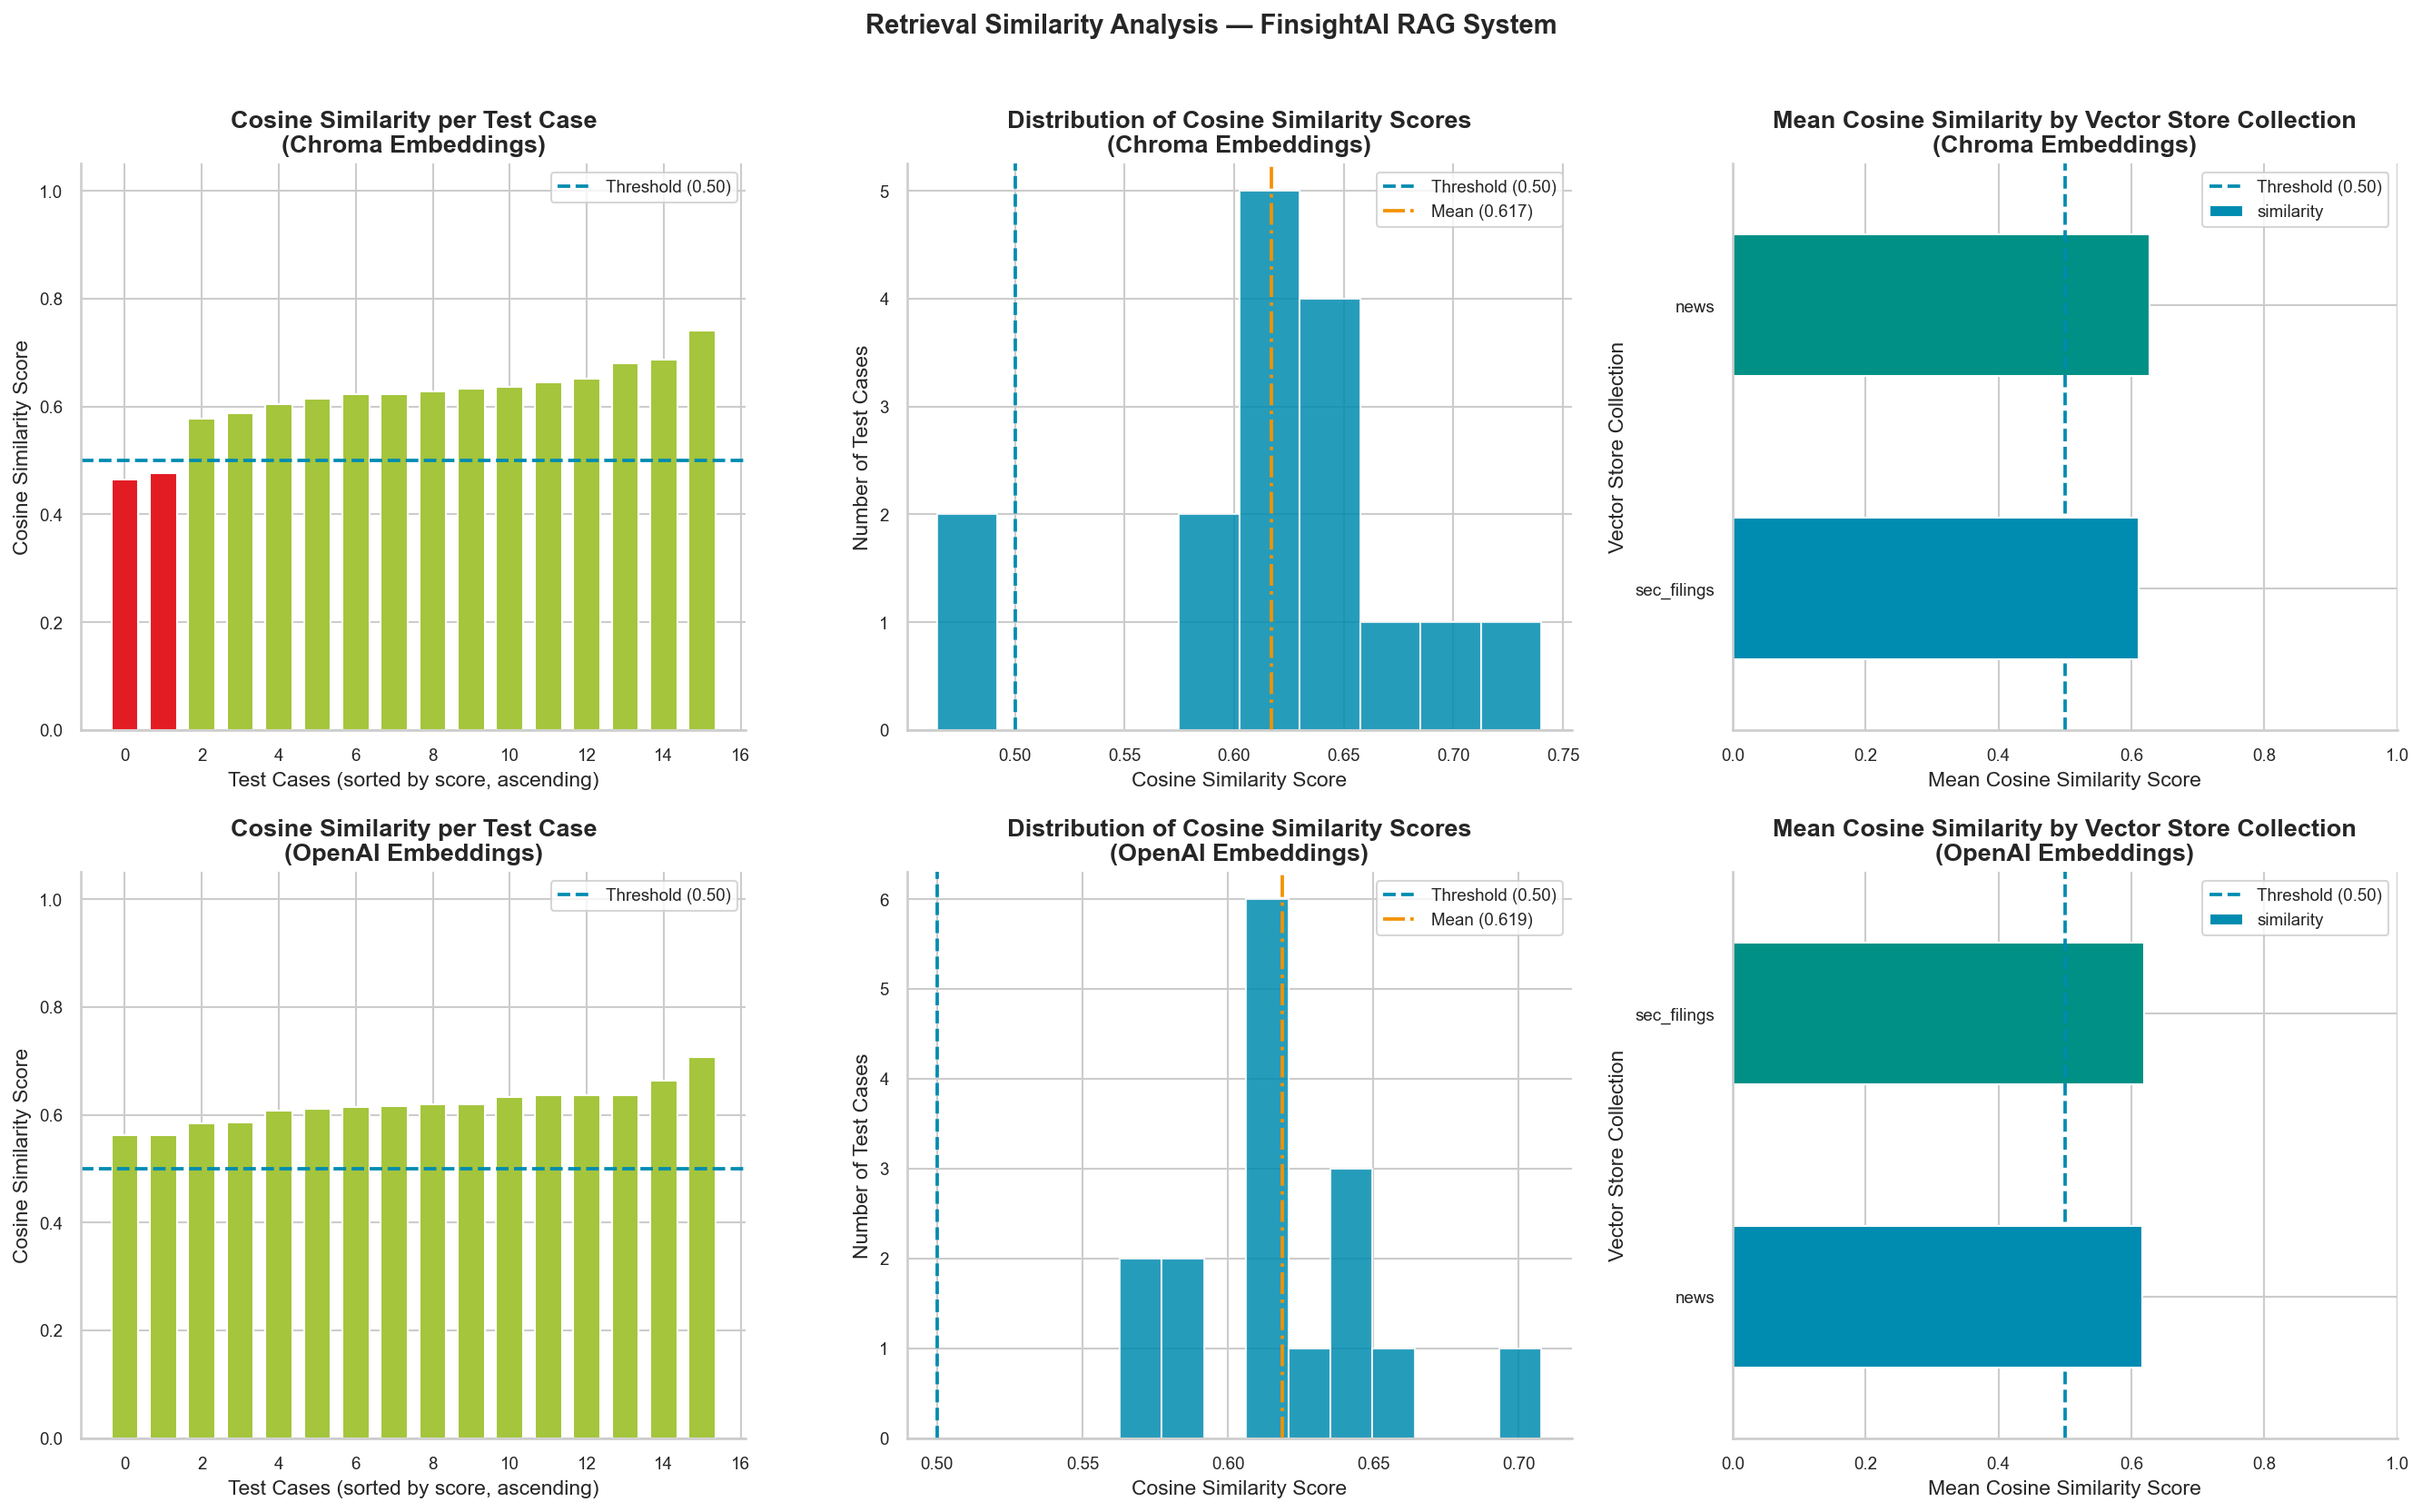

In [6]:
_pairs = list(similarity_result_iter())
if not _pairs:
    print("No similarity files — skipping charts.")
else:
    n = len(_pairs)
    fig, axes = plt.subplots(n, 3, figsize=(18, 5.5 * n))
    if n == 1:
        axes = np.array([axes])
    _threshold = THRESHOLDS["similarity"]

    for row, (emb_label, skey) in enumerate(_pairs):
        sim = loaded[skey].copy().merge(
            golden[["id", "expected_collection", "ticker"]], on="id", how="left"
        )
        bar_colors = [C_PASS if p else C_FAIL for p in sim["passed"]]
        order = sim.sort_values("similarity").index

        # --- Left: per-case bar chart ---
        ax = axes[row, 0]
        ax.bar(range(len(sim)), sim.loc[order, "similarity"],
               color=[bar_colors[i] for i in order], width=0.7)
        ax.axhline(_threshold, color=C_THRESHOLD, linestyle="--", linewidth=1.8,
                   label=f"Threshold ({_threshold:.2f})")
        ax.set_title(f"Cosine Similarity per Test Case\n({emb_label} Embeddings)")
        ax.set_xlabel("Test Cases (sorted by score, ascending)")
        ax.set_ylabel("Cosine Similarity Score")
        ax.set_ylim(0, 1.05)
        ax.legend()

        # --- Centre: histogram ---
        ax = axes[row, 1]
        ax.hist(sim["similarity"], bins=10, color=C_PRIMARY, edgecolor="white", alpha=0.85)
        ax.axvline(_threshold, color=C_THRESHOLD, linestyle="--", linewidth=1.8,
                   label=f"Threshold ({_threshold:.2f})")
        ax.axvline(sim["similarity"].mean(), color=C_MEAN, linestyle="-.", linewidth=1.8,
                   label=f"Mean ({sim['similarity'].mean():.3f})")
        ax.set_title(f"Distribution of Cosine Similarity Scores\n({emb_label} Embeddings)")
        ax.set_xlabel("Cosine Similarity Score")
        ax.set_ylabel("Number of Test Cases")
        ax.legend()

        # --- Right: mean by collection ---
        ax = axes[row, 2]
        coll_sim = sim.groupby("expected_collection")["similarity"].mean().sort_values()
        coll_colors = UTS_CYCLE[:len(coll_sim)]
        coll_sim.plot.barh(ax=ax, color=coll_colors)
        ax.axvline(_threshold, color=C_THRESHOLD, linestyle="--", linewidth=1.8,
                   label=f"Threshold ({_threshold:.2f})")
        ax.set_title(f"Mean Cosine Similarity by Vector Store Collection\n({emb_label} Embeddings)")
        ax.set_xlabel("Mean Cosine Similarity Score")
        ax.set_ylabel("Vector Store Collection")
        ax.set_xlim(0, 1.0)
        ax.legend()

    fig.suptitle("Retrieval Similarity Analysis — FinsightAI RAG System", y=1.01)
    plt.tight_layout()
    plt.savefig("similarity_scores_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()


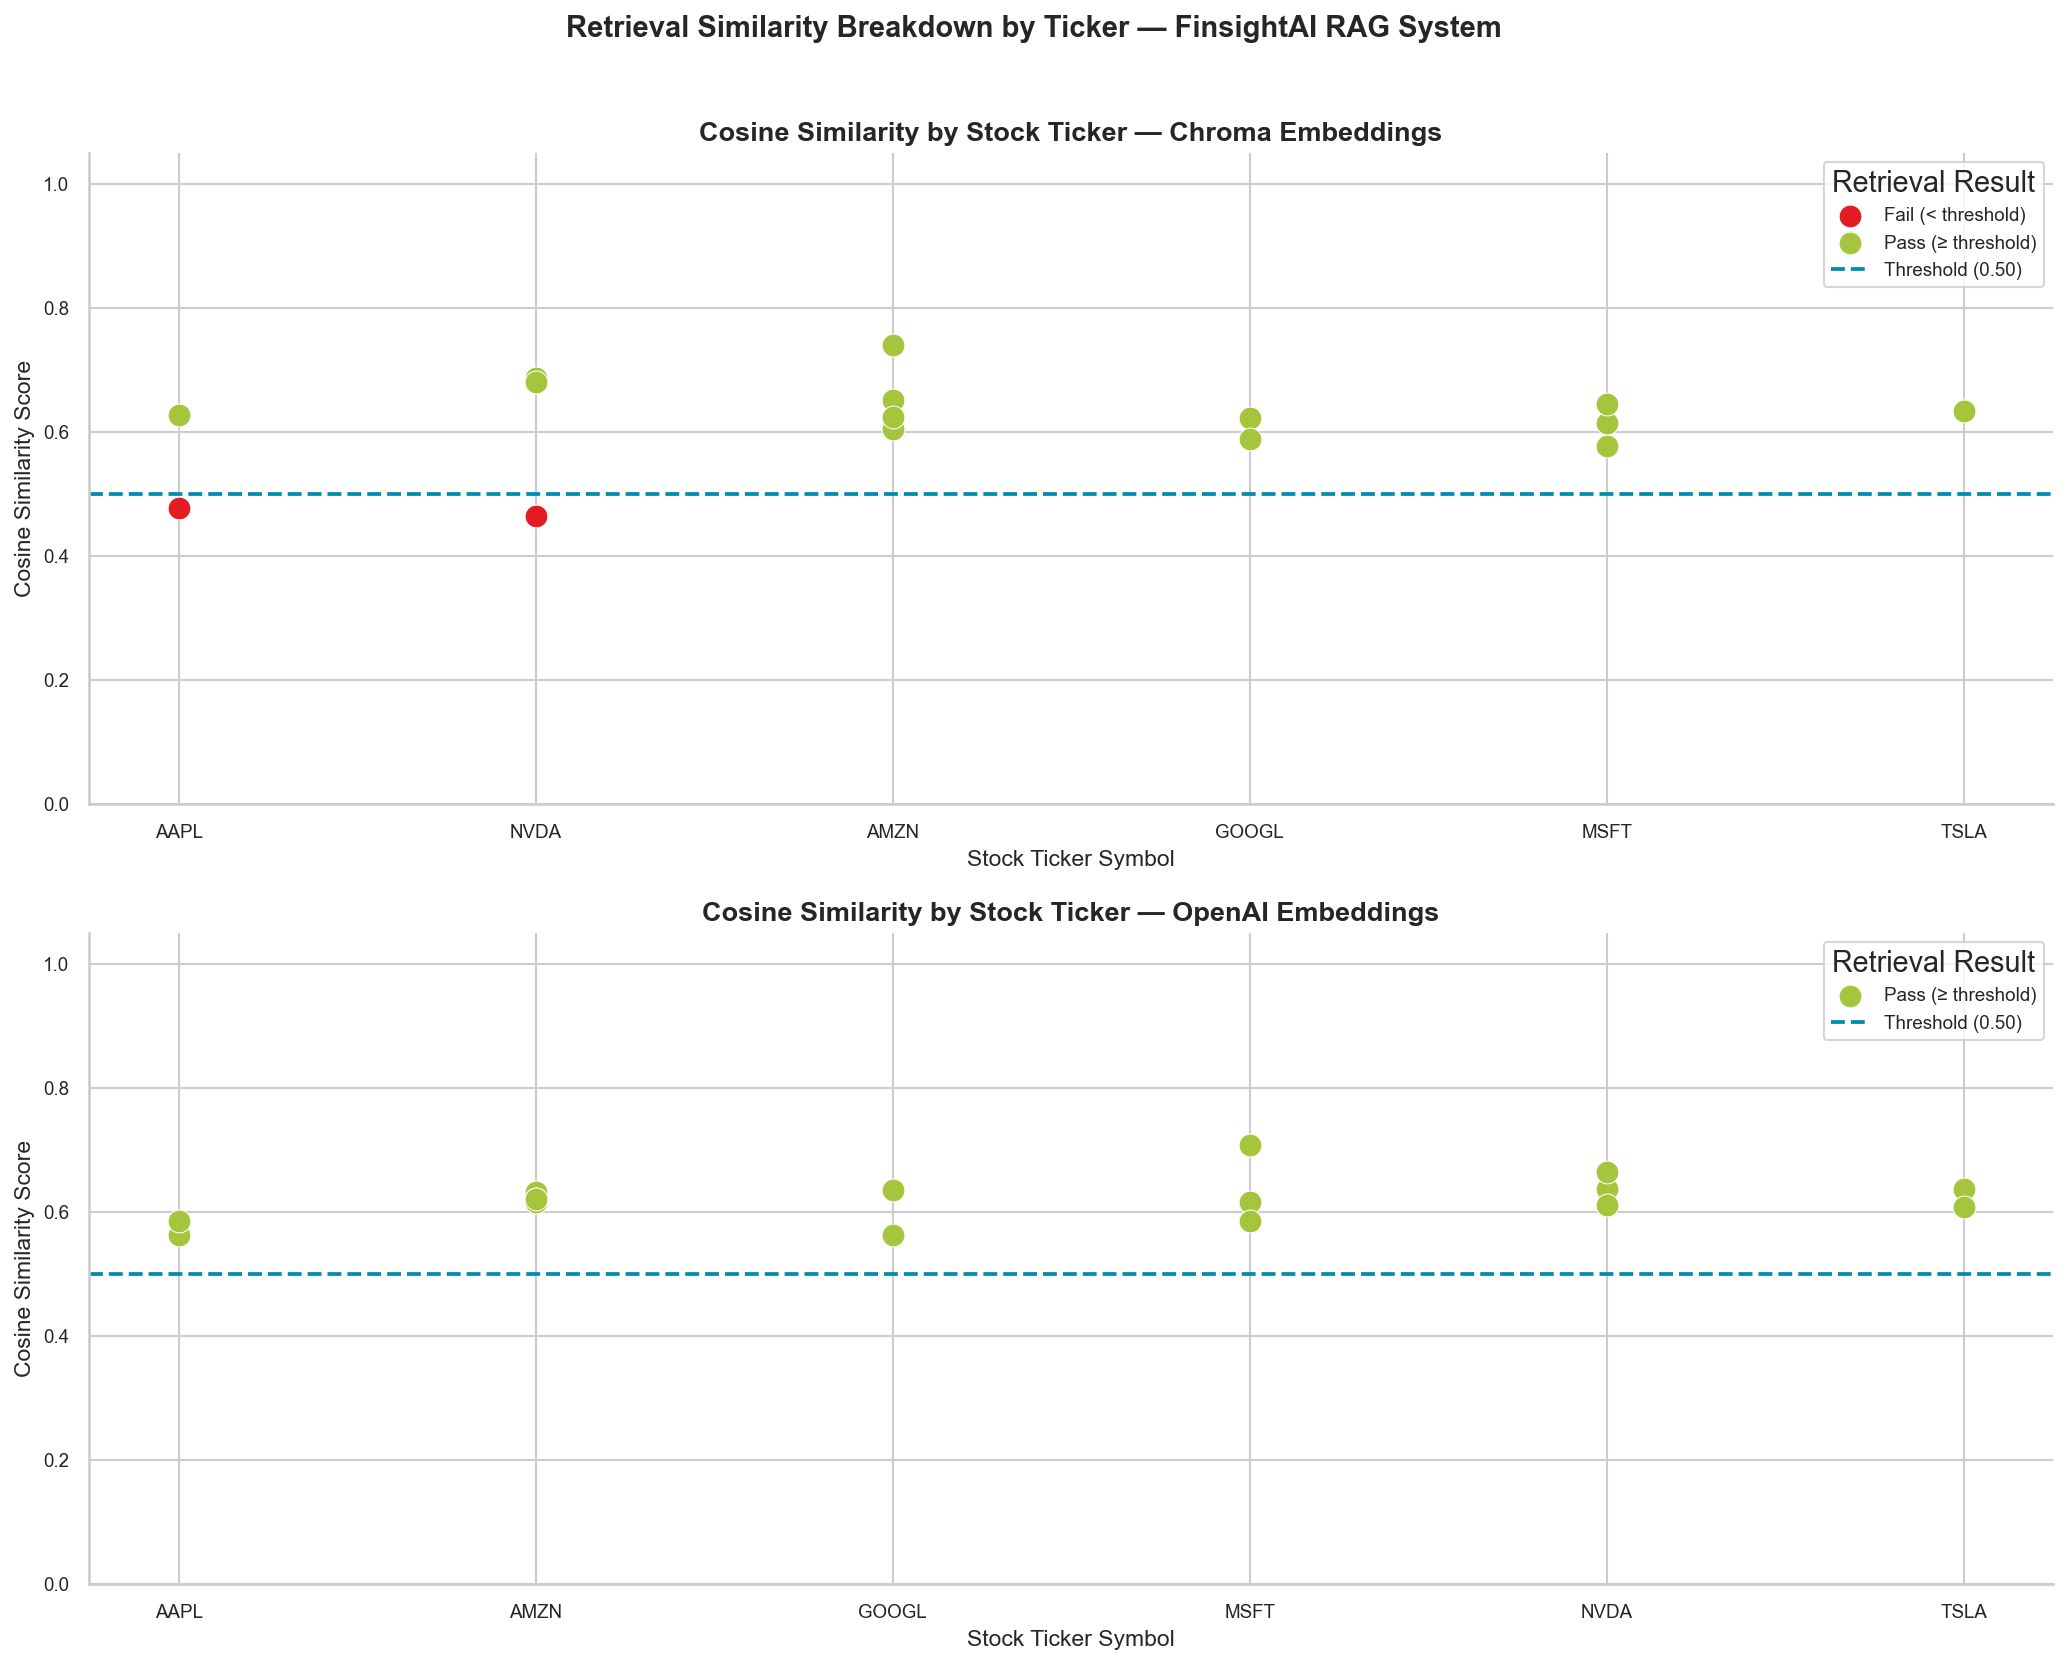

In [7]:
if _pairs:
    n = len(_pairs)
    fig, axes = plt.subplots(n, 1, figsize=(14, 5.5 * n))
    if n == 1:
        axes = [axes]
    _threshold = THRESHOLDS["similarity"]
    palette = {True: C_PASS, False: C_FAIL}

    for ax, (emb_label, skey) in zip(axes, _pairs):
        sim = loaded[skey].copy().merge(
            golden[["id", "expected_collection", "ticker"]], on="id", how="left"
        )
        for passed_val, group in sim.sort_values("ticker").groupby("passed"):
            ax.scatter(group["ticker"], group["similarity"],
                       color=palette[passed_val],
                       label="Pass (≥ threshold)" if passed_val else "Fail (< threshold)",
                       s=120, zorder=3, edgecolors="white", linewidths=0.5)
        ax.axhline(_threshold, color=C_THRESHOLD, linestyle="--", linewidth=1.8,
                   label=f"Threshold ({_threshold:.2f})")
        ax.set_title(f"Cosine Similarity by Stock Ticker — {emb_label} Embeddings")
        ax.set_xlabel("Stock Ticker Symbol")
        ax.set_ylabel("Cosine Similarity Score")
        ax.set_ylim(0, 1.05)
        ax.legend(title="Retrieval Result")

    fig.suptitle("Retrieval Similarity Breakdown by Ticker — FinsightAI RAG System", y=1.01)
    plt.tight_layout()
    plt.savefig("similarity_by_ticker.png", dpi=150, bbox_inches="tight")
    plt.show()


## 4  Hit Rate Analysis (SEC Filings & News)


SEC – Chroma (`hit_rate_sec_filings_chroma`)
  Hit rate : 90.0%  (9/10)  — PASS ✓
  Threshold: 70%


,id,question,hit,ticker,expected_collection
0,gd-001,What are Amazon's main risk factors according ...,True,AMZN,sec_filings
1,gd-003,What are the key growth strategies mentioned i...,True,MSFT,sec_filings
2,gd-007,What capital expenditures did Amazon report in...,False,AMZN,sec_filings
3,gd-009,What does Google's 10-K say about their AI str...,True,GOOGL,sec_filings
4,gd-012,Summarise NVDA's business model from its 10-K,True,NVDA,sec_filings
5,gd-034,What does Amazon's 10-K say about AWS revenue ...,True,AMZN,sec_filings
6,gd-035,What does Tesla's 10-K say about manufacturing...,True,TSLA,sec_filings
7,gd-036,What does NVIDIA's 10-K disclose about export ...,True,NVDA,sec_filings
8,gd-037,What are Apple's revenue recognition policies ...,True,AAPL,sec_filings
9,gd-038,What does Microsoft's 10-K say about cybersecu...,True,MSFT,sec_filings


/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_16112/65921832.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_16112/65921832.py:62: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(f"hit_rate_{safe_name}_analysis.png", dpi=150, bbox_inches="tight")
/Users/juansebastianvargastorres/Desktop/UTS_subjects/Semester_2/NLP/Assignment2/finsightAI/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


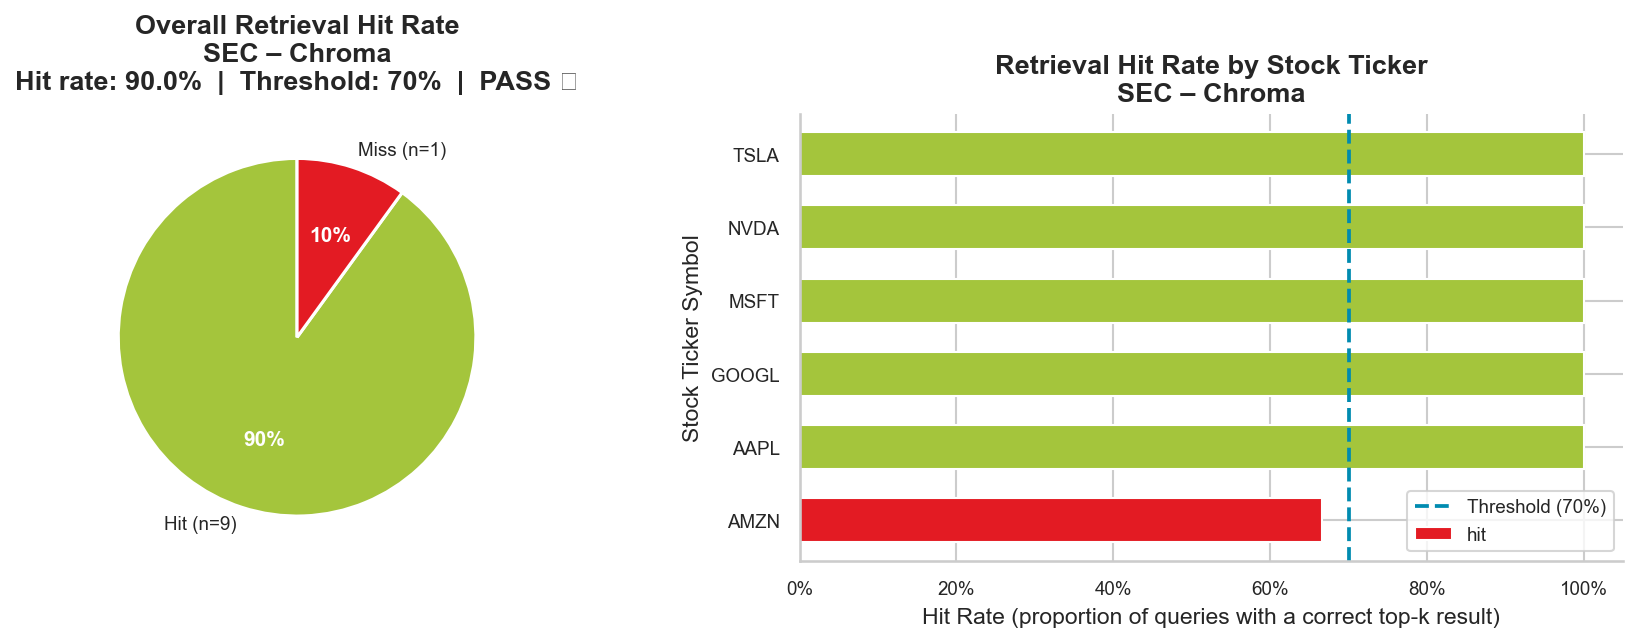


SEC – OpenAI (`hit_rate_sec_filings_openai`)
  Hit rate : 100.0%  (10/10)  — PASS ✓
  Threshold: 70%


,id,question,hit,ticker,expected_collection
0,gd-001,What are Amazon's main risk factors according ...,True,AMZN,sec_filings
1,gd-003,What are the key growth strategies mentioned i...,True,MSFT,sec_filings
2,gd-007,What capital expenditures did Amazon report in...,True,AMZN,sec_filings
3,gd-009,What does Google's 10-K say about their AI str...,True,GOOGL,sec_filings
4,gd-012,Summarise NVDA's business model from its 10-K,True,NVDA,sec_filings
5,gd-034,What does Amazon's 10-K say about AWS revenue ...,True,AMZN,sec_filings
6,gd-035,What does Tesla's 10-K say about manufacturing...,True,TSLA,sec_filings
7,gd-036,What does NVIDIA's 10-K disclose about export ...,True,NVDA,sec_filings
8,gd-037,What are Apple's revenue recognition policies ...,True,AAPL,sec_filings
9,gd-038,What does Microsoft's 10-K say about cybersecu...,True,MSFT,sec_filings


/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_16112/65921832.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_16112/65921832.py:62: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(f"hit_rate_{safe_name}_analysis.png", dpi=150, bbox_inches="tight")
/Users/juansebastianvargastorres/Desktop/UTS_subjects/Semester_2/NLP/Assignment2/finsightAI/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


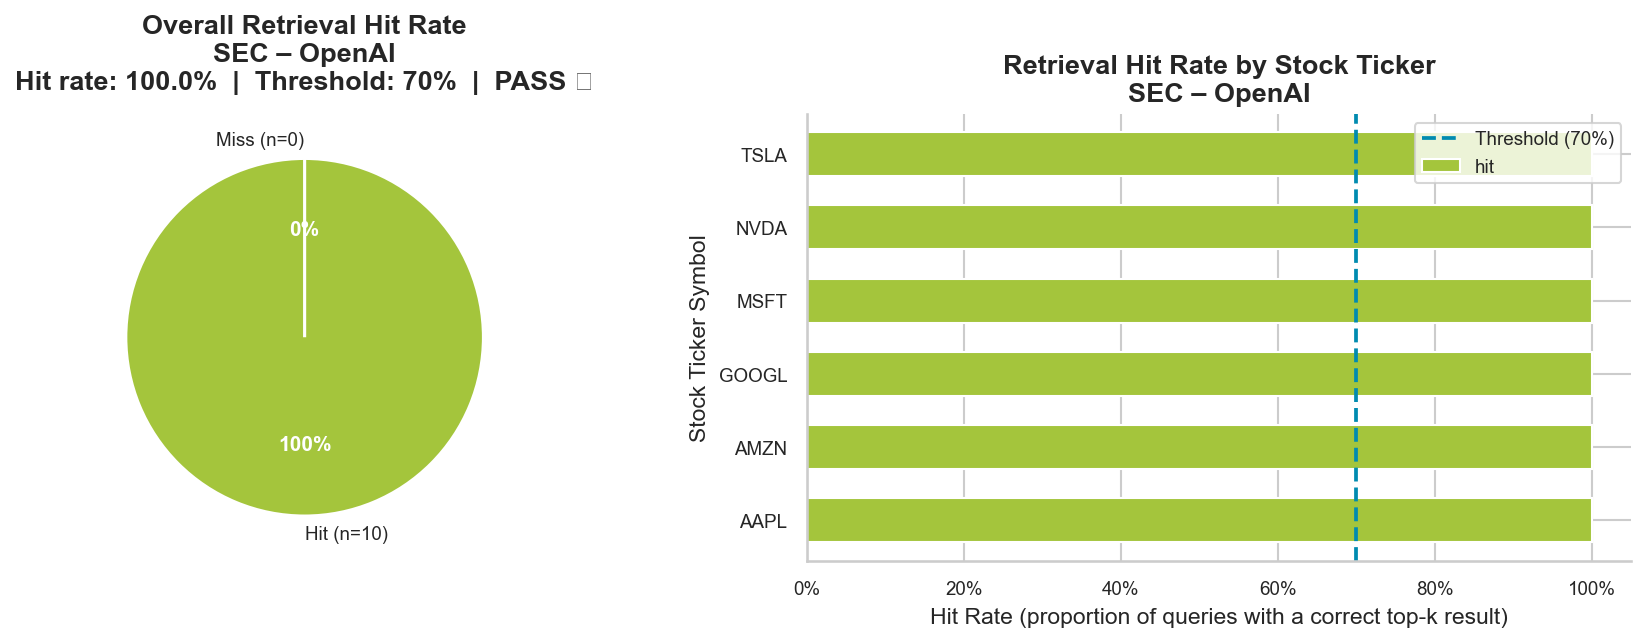


News – Chroma (`hit_rate_news_chroma`)
  Hit rate : 100.0%  (6/6)  — PASS ✓
  Threshold: 70%


,id,question,hit,ticker,expected_collection
0,gd-005,What recent news sentiment surrounds Tesla?,True,TSLA,news
1,gd-010,What are the recent news themes for Apple?,True,AAPL,news
2,gd-039,What is the latest news about NVIDIA's AI chip...,True,NVDA,news
3,gd-040,What is the recent news sentiment around Micro...,True,MSFT,news
4,gd-041,What recent news has affected Amazon's stock p...,True,AMZN,news
5,gd-042,What are analysts saying about Google's earnings?,True,GOOGL,news


/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_16112/65921832.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_16112/65921832.py:62: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(f"hit_rate_{safe_name}_analysis.png", dpi=150, bbox_inches="tight")
/Users/juansebastianvargastorres/Desktop/UTS_subjects/Semester_2/NLP/Assignment2/finsightAI/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


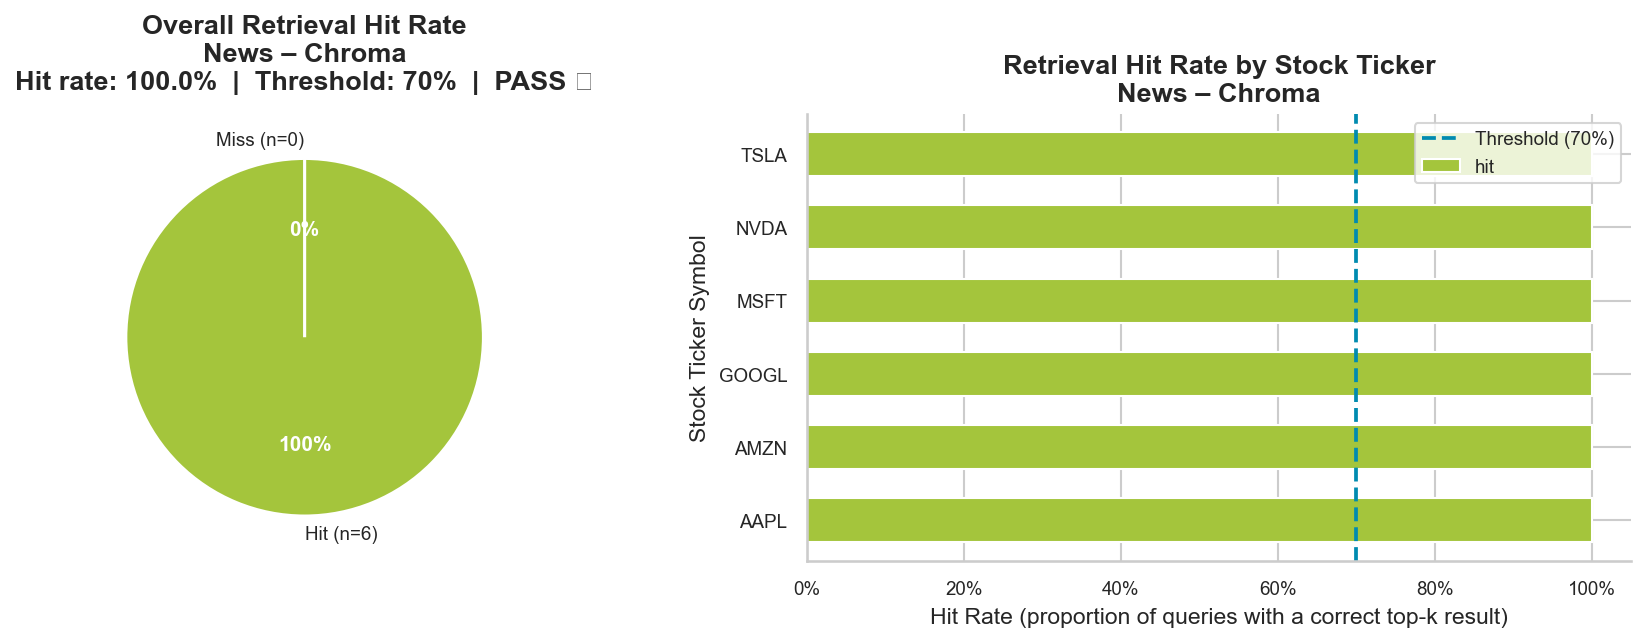


News – OpenAI (`hit_rate_news_openai`)
  Hit rate : 100.0%  (6/6)  — PASS ✓
  Threshold: 70%


,id,question,hit,ticker,expected_collection
0,gd-005,What recent news sentiment surrounds Tesla?,True,TSLA,news
1,gd-010,What are the recent news themes for Apple?,True,AAPL,news
2,gd-039,What is the latest news about NVIDIA's AI chip...,True,NVDA,news
3,gd-040,What is the recent news sentiment around Micro...,True,MSFT,news
4,gd-041,What recent news has affected Amazon's stock p...,True,AMZN,news
5,gd-042,What are analysts saying about Google's earnings?,True,GOOGL,news


/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_16112/65921832.py:61: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_16112/65921832.py:62: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(f"hit_rate_{safe_name}_analysis.png", dpi=150, bbox_inches="tight")
/Users/juansebastianvargastorres/Desktop/UTS_subjects/Semester_2/NLP/Assignment2/finsightAI/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


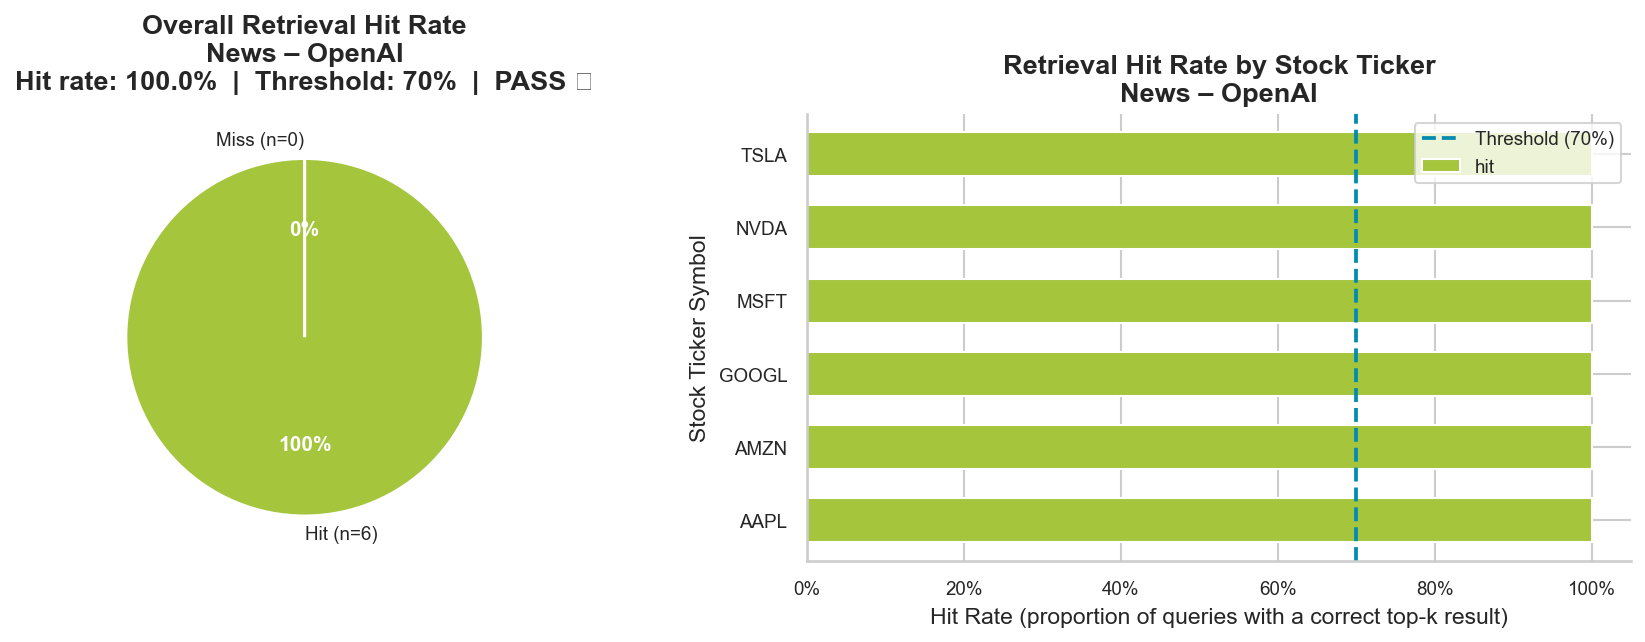

In [8]:
def analyse_hit_rate(prefix: str, label: str):
    if prefix not in loaded:
        print(f"No {prefix} file found — skipping.")
        return

    df = loaded[prefix].copy()
    if "hit" not in df.columns:
        print(f"  [{label}] No 'hit' column — columns: {df.columns.tolist()}")
        return
    df = df.merge(golden[["id", "ticker", "expected_collection"]], on="id", how="left")

    hit_rate = df["hit"].mean()
    threshold = THRESHOLDS["hit_rate"]
    status = "PASS ✓" if hit_rate >= threshold else "FAIL ✗"

    print(f"\n{label} (`{prefix}`)")
    print(f"  Hit rate : {hit_rate:.1%}  ({df['hit'].sum()}/{len(df)})  — {status}")
    print(f"  Threshold: {threshold:.0%}")
    display(df)

    safe_name = re.sub(r"[^\w\-]+", "_", prefix)[:80]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # --- Pie: overall hit vs miss ---
    n_hit  = int(df["hit"].sum())
    n_miss = len(df) - n_hit
    wedge_colors = [C_PASS, C_FAIL]
    wedges, texts, autotexts = axes[0].pie(
        [n_hit, n_miss],
        labels=[f"Hit (n={n_hit})", f"Miss (n={n_miss})"],
        colors=wedge_colors,
        autopct="%1.0f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    for at in autotexts:
        at.set_fontsize(10)
        at.set_color("white")
        at.set_fontweight("bold")
    axes[0].set_title(
        f"Overall Retrieval Hit Rate\n{label}\n"
        f"Hit rate: {hit_rate:.1%}  |  Threshold: {threshold:.0%}  |  {status}",
        pad=12,
    )

    # --- Bar: hit rate by ticker ---
    if "ticker" in df.columns and df["ticker"].notna().any():
        ticker_hit = df.groupby("ticker")["hit"].mean().sort_values()
        bar_colors = [C_PASS if v >= threshold else C_FAIL for v in ticker_hit]
        ticker_hit.plot.barh(ax=axes[1], color=bar_colors, width=0.6)
        axes[1].axvline(threshold, color=C_THRESHOLD, linestyle="--", linewidth=1.8,
                        label=f"Threshold ({threshold:.0%})")
        axes[1].set_title(f"Retrieval Hit Rate by Stock Ticker\n{label}")
        axes[1].set_xlabel("Hit Rate (proportion of queries with a correct top-k result)")
        axes[1].set_ylabel("Stock Ticker Symbol")
        axes[1].set_xlim(0, 1.05)
        axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        axes[1].legend()
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(f"hit_rate_{safe_name}_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()


for disp, hkey in hit_rate_result_iter():
    analyse_hit_rate(hkey, disp)


## 5  RAGAS Metric Analysis

Faithfulness: 0.4326  (threshold 0.8)  — FAIL ✗


,question,answer,contexts,ground_truth,faithfulness
0,What are Amazon's main risk factors according ...,"Amazon’s 10-K highlights a broad set of risks,...","[""I've been consistently bullish on Amazon sto...",Amazon's main risk factors include intense com...,0.8571
1,What are the key growth strategies mentioned i...,Microsoft’s 10-K points to a few core growth s...,['\u200bMicrosoft Corporation (NASDAQ:MSFT) is...,Microsoft's growth strategies include expandin...,0.4167
2,What recent news sentiment surrounds Tesla?,Here’s the recent news sentiment around Tesla:...,"['After rallying 45% in 2025, TSLA’s momentum ...",Recent Tesla news includes coverage of vehicle...,0.5000
3,What capital expenditures did Amazon report in...,Amazon reported **cash capital expenditures of...,['exchange rates. Cash provided by (used in) i...,Amazon's 10-K discloses significant capital ex...,0.6667
4,What does Google's 10-K say about their AI str...,"Google’s 10-K says AI is a core, company-wide ...",['Mega-Cap Tech Earnings: AI Investment Valida...,Google's 10-K discusses investments in generat...,0.5455
5,What are the recent news themes for Apple?,Here are the main recent news themes for Apple...,"[""Alphabet's search advertising resilience ami...","Recent AAPL news themes include iPhone sales, ...",0.4167
6,Summarise NVDA's business model from its 10-K,NVIDIA’s 10-K describes a business built aroun...,['The initiative positions NVIDIA as a large s...,NVIDIA designs and sells GPUs and system-on-ch...,0.0000
7,What does Amazon's 10-K say about AWS revenue ...,Amazon’s 10-K says AWS revenue growth remained...,"[""First, Amazon should see continued accelerat...",Amazon's 10-K discusses AWS as its most profit...,0.2857
8,What does Tesla's 10-K say about manufacturing...,Tesla’s 10-K describes manufacturing risk as a...,['Management cautioned that this investment cy...,Tesla's 10-K describes manufacturing risks inc...,0.6667
9,What does NVIDIA's 10-K disclose about export ...,NVIDIA’s 10-K says export controls are a mater...,"[""\u200bNVIDIA Corp. (NASDAQ:NVDA) designs and...",NVIDIA's 10-K discloses material risks from US...,0.5000


Answer Relevancy: 0.7333  (threshold 0.8)  — FAIL ✗


,question,answer,ground_truth,answer_relevancy
0,What are Amazon's main risk factors according ...,"Amazon’s 10-K risk discussion is broad, but th...",Amazon's main risk factors include intense com...,0.8374
1,What was Apple's total revenue in fiscal year ...,Apple’s total revenue in fisca...,Apple reported total net sales of $391.0 billi...,0.0000
2,What are the key growth strategies mentioned i...,Microsoft’s 10-K points to a few core growth s...,Microsoft's growth strategies include expandin...,0.9358
3,What is NVIDIA's current market capitalisation...,NVIDIA’s current market capitalisation is **$5...,NVIDIA's market capitalisation and P/E ratio c...,0.8812
4,What recent news sentiment surrounds Tesla?,Tesla’s recent news sentiment looks **mixed to...,Recent Tesla news includes coverage of vehicle...,0.9078
5,Show me Apple's historical stock price for the...,Here’s Apple’s historical stock price for the ...,The agent should use get_price_history with pe...,0.9154
6,What capital expenditures did Amazon report in...,Amazon reported **cash capital expenditures of...,Amazon's 10-K discloses significant capital ex...,0.7790
7,What is my current portfolio balance?,Your current paper portfolio balance is:\n\n- ...,The agent should call get_portfolio to retriev...,0.7817
8,What does Google's 10-K say about their AI str...,Alphabet’s 10-K describes AI as a core part of...,Google's 10-K discusses investments in generat...,0.7713
9,What are the recent news themes for Apple?,Here are the main recent news themes for Apple...,"Recent AAPL news themes include iPhone sales, ...",0.9732


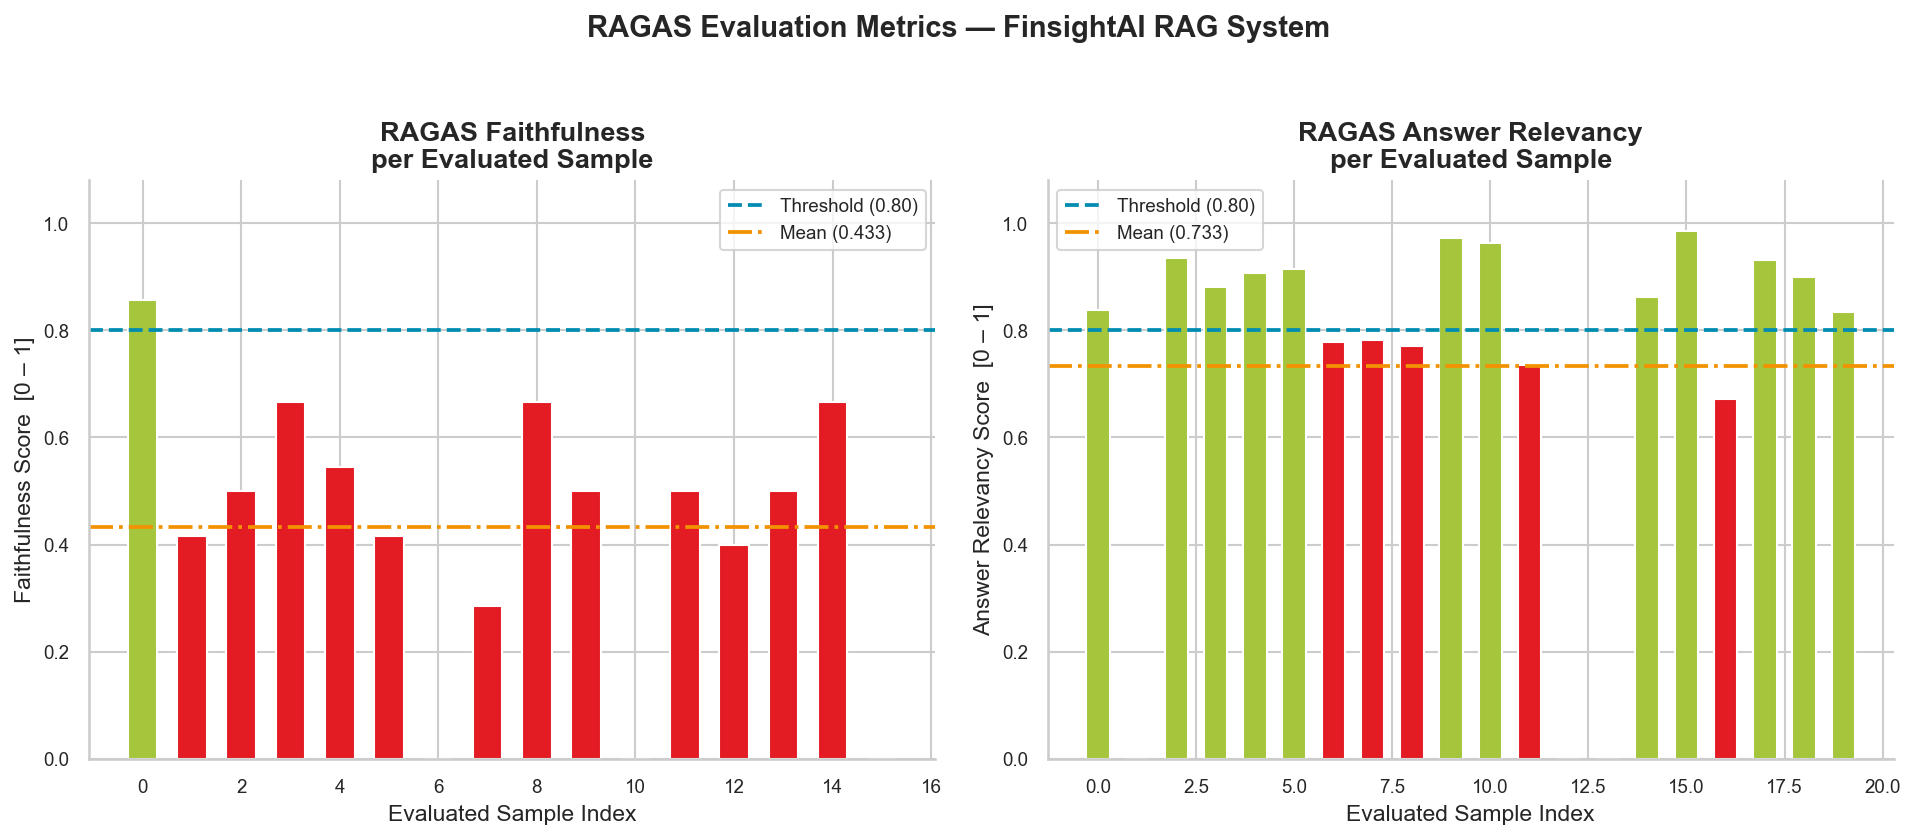

In [9]:
RAGAS_TESTS = [
    ("ragas_faithfulness",   "faithfulness",    THRESHOLDS["faithfulness"],    "Faithfulness"),
    ("ragas_relevancy",      "answer_relevancy", THRESHOLDS["answer_relevancy"], "Answer Relevancy")
]

ragas_summaries = []

for prefix, metric_col, threshold, label in RAGAS_TESTS:
    if prefix not in loaded:
        print(f"No {prefix} file — run the test suite to generate it.")
        continue

    df = loaded[prefix].copy()
    if metric_col not in df.columns:
        print(f"  Column '{metric_col}' not found in {prefix}. Available: {df.columns.tolist()}")
        continue

    avg = df[metric_col].mean()
    status = "PASS ✓" if avg >= threshold else "FAIL ✗"
    ragas_summaries.append({"Metric": label, "Score": avg, "Threshold": threshold, "Status": status})

    print(f"{label}: {avg:.4f}  (threshold {threshold})  — {status}")
    display(df)

if ragas_summaries:
    n_tests = len(ragas_summaries)
    fig, axes = plt.subplots(1, n_tests, figsize=(6.5 * n_tests, 5.5))
    if n_tests == 1:
        axes = [axes]

    for ax, (prefix, metric_col, threshold, label) in zip(axes, RAGAS_TESTS):
        if prefix not in loaded or metric_col not in loaded[prefix].columns:
            ax.axis("off")
            continue
        df = loaded[prefix]
        scores = df[metric_col].dropna()
        bar_colors = [C_PASS if s >= threshold else C_FAIL for s in scores]
        ax.bar(range(len(scores)), scores, color=bar_colors, width=0.6)
        ax.axhline(threshold, color=C_THRESHOLD, linestyle="--", linewidth=1.8,
                   label=f"Threshold ({threshold:.2f})")
        ax.axhline(scores.mean(), color=C_MEAN, linestyle="-.", linewidth=1.8,
                   label=f"Mean ({scores.mean():.3f})")
        ax.set_ylim(0, 1.08)
        ax.set_title(f"RAGAS {label}\nper Evaluated Sample")
        ax.set_xlabel("Evaluated Sample Index")
        ax.set_ylabel(f"{label} Score  [0 – 1]")
        ax.legend()

    fig.suptitle("RAGAS Evaluation Metrics — FinsightAI RAG System", y=1.02)
    plt.tight_layout()
    plt.savefig("ragas_metrics_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

In [10]:
import pandas as pd

# Read the "ragas_faithfulness_20260427.xlsx" file
faithfulness_df = pd.read_excel("ragas_faithfulness_20260427.xlsx")

# Optionally display the DataFrame to verify
display(faithfulness_df)

for col in faithfulness_df.columns:
    print(f"{col}: {faithfulness_df.iloc[0][col]}")

,question,answer,contexts,ground_truth,faithfulness
0,What are Amazon's main risk factors according ...,Amazon’s 10-K highlights a broad set of risk f...,"[""I've been consistently bullish on Amazon sto...",Amazon's main risk factors include intense com...,0.473684
1,What are the key growth strategies mentioned i...,Microsoft’s 10-K points to a few clear growth ...,['The outcome could influence how AI partnersh...,Microsoft's growth strategies include expandin...,0.266667
2,What recent news sentiment surrounds Tesla?,"```news\n[\n {\n ""title"": ""Better Later Th...","['Tesla’s Q1 2026 earnings, released on April ...",Recent Tesla news includes coverage of vehicle...,0.142857
3,What capital expenditures did Amazon report in...,Amazon reported **cash capital expenditures of...,"[""The acceleration in capex necessarily has to...",Amazon's 10-K discloses significant capital ex...,0.666667
4,What does Google's 10-K say about their AI str...,Google’s 10-K says AI is central to Alphabet’s...,"[""Google's strategic position in all of this\n...",Google's 10-K discusses investments in generat...,0.625000
5,What are the recent news themes for Apple?,"```news\n[\n {\n ""title"": ""Mega-Cap Earnin...","[""Alphabet's search advertising resilience ami...","Recent AAPL news themes include iPhone sales, ...",0.428571
6,Summarise NVDA's business model from its 10-K,NVIDIA’s 10-K describes it as an accelerated c...,['The initiative positions NVIDIA as a large s...,NVIDIA designs and sells GPUs and system-on-ch...,0.000000
7,What does Amazon's 10-K say about AWS revenue ...,Amazon’s 10-K says AWS revenue growth remained...,"[""First, Amazon should see continued accelerat...",Amazon's 10-K discusses AWS as its most profit...,0.333333
8,What does Tesla's 10-K say about manufacturing...,Tesla’s 10-K says manufacturing risk is a core...,"[""You have to play the long game with Tesla's ...",Tesla's 10-K describes manufacturing risks inc...,0.857143
9,What does NVIDIA's 10-K disclose about export ...,NVIDIA’s 10-K says export controls are a meani...,"[""Stay updated on the most important news stor...",NVIDIA's 10-K discloses material risks from US...,0.333333


question: What are Amazon's main risk factors according to the 10-K?
answer: Amazon’s 10-K highlights a broad set of risk factors, but the main ones appear to be:

1. **Macroeconomic and geopolitical conditions**
   - Global economic weakness, inflation, interest rates, foreign exchange swings, energy prices, tariff/trade policies, and world events can all hurt demand and margins.

2. **Competitive pressure**
   - Amazon faces intense competition across e-commerce, cloud, advertising, logistics, and newer technology areas, which can pressure pricing, growth, and profitability.

3. **Demand and spending volatility**
   - Customer demand can shift quickly, including third-party s...
contexts: ["I've been consistently bullish on Amazon stock this year, and the Meta and Anthropic announcements strengthen the long-term story. But after the stock's recent surge, I'm growing more wary of the valuation. Anyone buying today may want to consider keeping their position small -- especially given t

## 6  Tool Call Accuracy Analysis

Tool Call Accuracy: 0.9500  (threshold 0.7)  — PASS ✓


,id,question,expected_tool_x,ai_tools,tool_call_accuracy,passed,expected_tool_y,ticker
0,gd-001,What are Amazon's main risk factors according ...,vector_store,vector_store,1,True,vector_store,AMZN
1,gd-002,What was Apple's total revenue in fiscal year ...,get_fundamentals,get_fundamentals,1,True,get_fundamentals,AAPL
2,gd-003,What are the key growth strategies mentioned i...,vector_store,vector_store,1,True,vector_store,MSFT
3,gd-004,What is NVIDIA's current market capitalisation...,get_company_financials,get_company_financials,1,True,get_company_financials,NVDA
4,gd-005,What recent news sentiment surrounds Tesla?,vector_store,vector_store,1,True,vector_store,TSLA
5,gd-006,Show me Apple's historical stock price for the...,get_price_history,get_price_history,1,True,get_price_history,AAPL
6,gd-007,What capital expenditures did Amazon report in...,vector_store,"vector_store, get_fundamentals",0,False,vector_store,AMZN
7,gd-008,What is my current portfolio balance?,get_portfolio,get_portfolio,1,True,get_portfolio,NaN
8,gd-009,What does Google's 10-K say about their AI str...,vector_store,vector_store,1,True,vector_store,GOOGL
9,gd-010,What are the recent news themes for Apple?,vector_store,vector_store,1,True,vector_store,AAPL


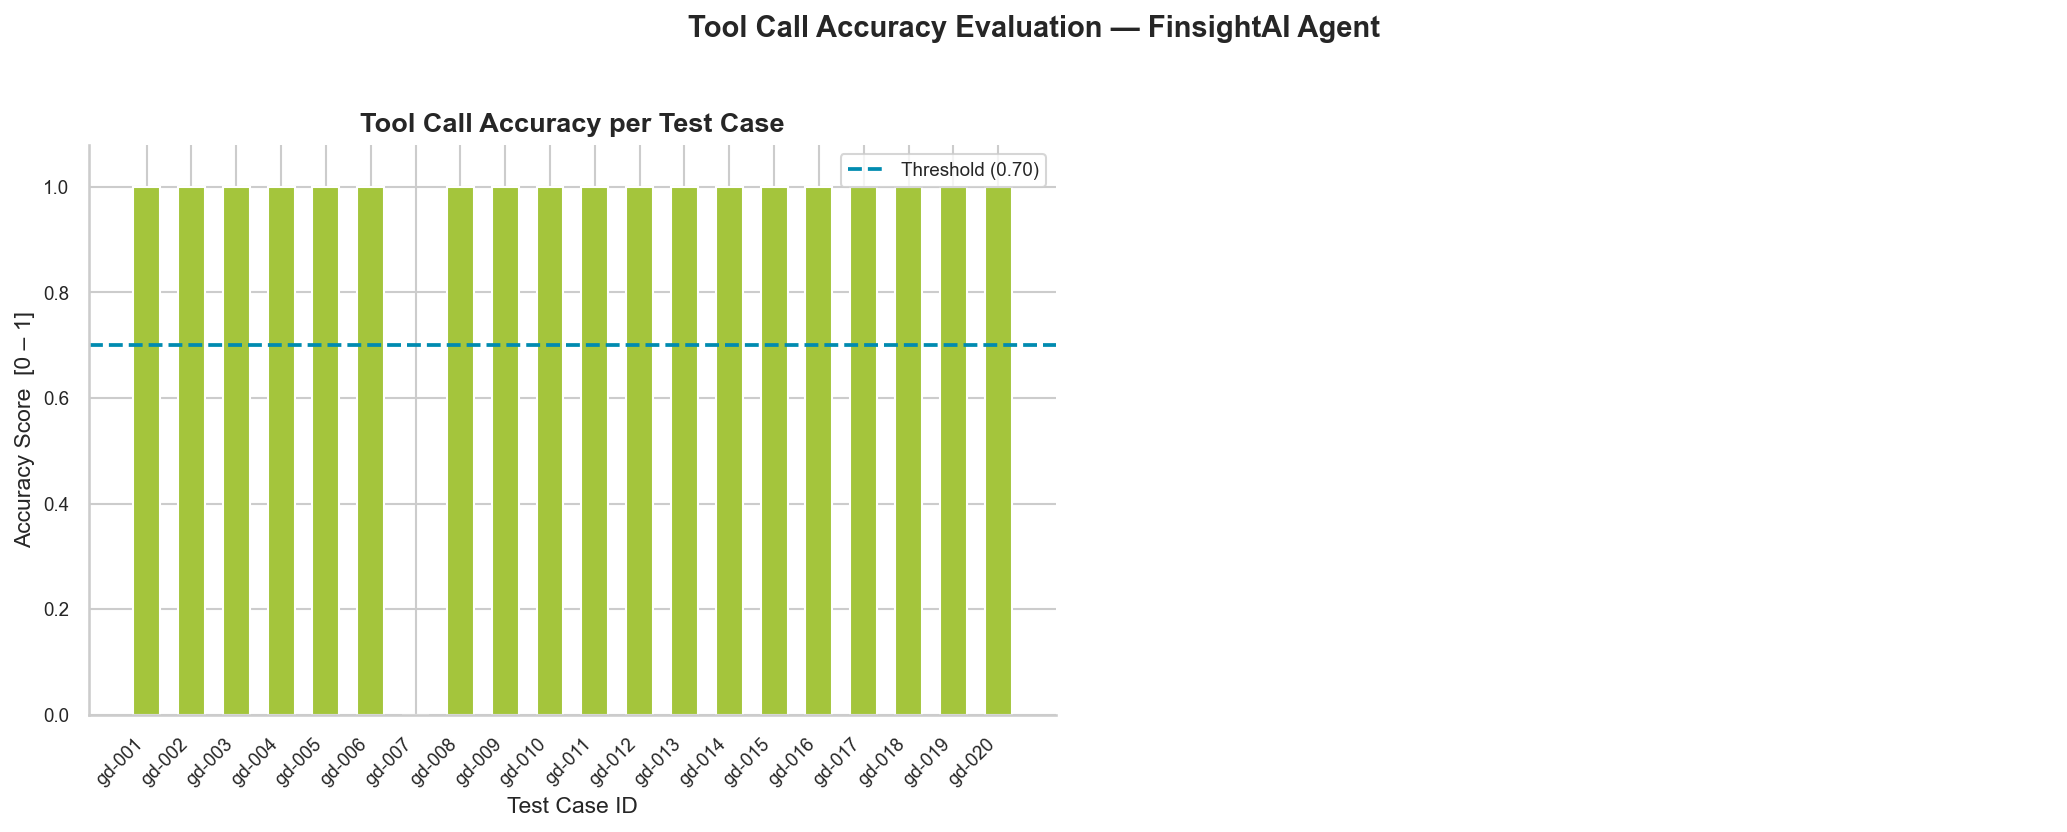

In [12]:
if "tool_call_accuracy" not in loaded:
    print("No tool_call_accuracy file found — skipping.")
else:
    tca = loaded["tool_call_accuracy"].copy()
    tca = tca.merge(golden[["id", "expected_tool", "ticker"]], on="id", how="left")

    metric_col = "tool_call_accuracy"
    avg_score = tca[metric_col].mean()
    threshold = THRESHOLDS["tool_accuracy"]
    status = "PASS ✓" if avg_score >= threshold else "FAIL ✗"

    print(f"Tool Call Accuracy: {avg_score:.4f}  (threshold {threshold})  — {status}")
    display(tca)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # --- Left: per-case accuracy ---
    bar_colors = [C_PASS if s >= threshold else C_FAIL for s in tca[metric_col]]
    axes[0].bar(range(len(tca)), tca[metric_col], color=bar_colors, width=0.6)
    axes[0].set_xticks(range(len(tca)))
    axes[0].set_xticklabels(tca["id"], rotation=45, ha="right")
    axes[0].axhline(threshold, color=C_THRESHOLD, linestyle="--", linewidth=1.8,
                    label=f"Threshold ({threshold:.2f})")
    axes[0].set_title("Tool Call Accuracy per Test Case")
    axes[0].set_xlabel("Test Case ID")
    axes[0].set_ylabel("Accuracy Score  [0 – 1]")
    axes[0].set_ylim(0, 1.08)
    axes[0].legend()

    # --- Right: mean by expected tool ---
    if "expected_tool" in tca.columns:
        tool_scores = tca.groupby("expected_tool")[metric_col].mean().sort_values()
        t_colors = [C_PASS if v >= threshold else C_FAIL for v in tool_scores]
        tool_scores.plot.barh(ax=axes[1], color=t_colors, width=0.6)
        axes[1].axvline(threshold, color=C_THRESHOLD, linestyle="--", linewidth=1.8,
                        label=f"Threshold ({threshold:.2f})")
        axes[1].set_title("Mean Tool Call Accuracy by Expected Tool")
        axes[1].set_xlabel("Mean Accuracy Score  [0 – 1]")
        axes[1].set_ylabel("Expected Tool (MCP Tool Name)")
        axes[1].set_xlim(0, 1.08)
        axes[1].legend()
    else:
        axes[1].axis("off")

    fig.suptitle("Tool Call Accuracy Evaluation — FinsightAI Agent", y=1.01)
    plt.tight_layout()
    plt.savefig("tool_call_accuracy_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7  Response Time Analysis

Average response time : 7.339 s
Median  response time : 7.695 s
n = 21 cases


,id,question,response_time_s,passed
0,gd-001,What are Amazon's main risk factors according ...,14.9856,False
1,gd-002,What was Apple's total revenue in fiscal year ...,6.2487,True
2,gd-003,What are the key growth strategies mentioned i...,7.8410,True
3,gd-004,What is NVIDIA's current market capitalisation...,4.5332,True
4,gd-005,What recent news sentiment surrounds Tesla?,7.6947,True
5,gd-006,Show me Apple's historical stock price for the...,7.7690,True
6,gd-007,What capital expenditures did Amazon report in...,9.2508,True
7,gd-008,What is my current portfolio balance?,7.3787,True
8,gd-009,What does Google's 10-K say about their AI str...,8.1927,True
9,gd-010,What are the recent news themes for Apple?,9.4119,True


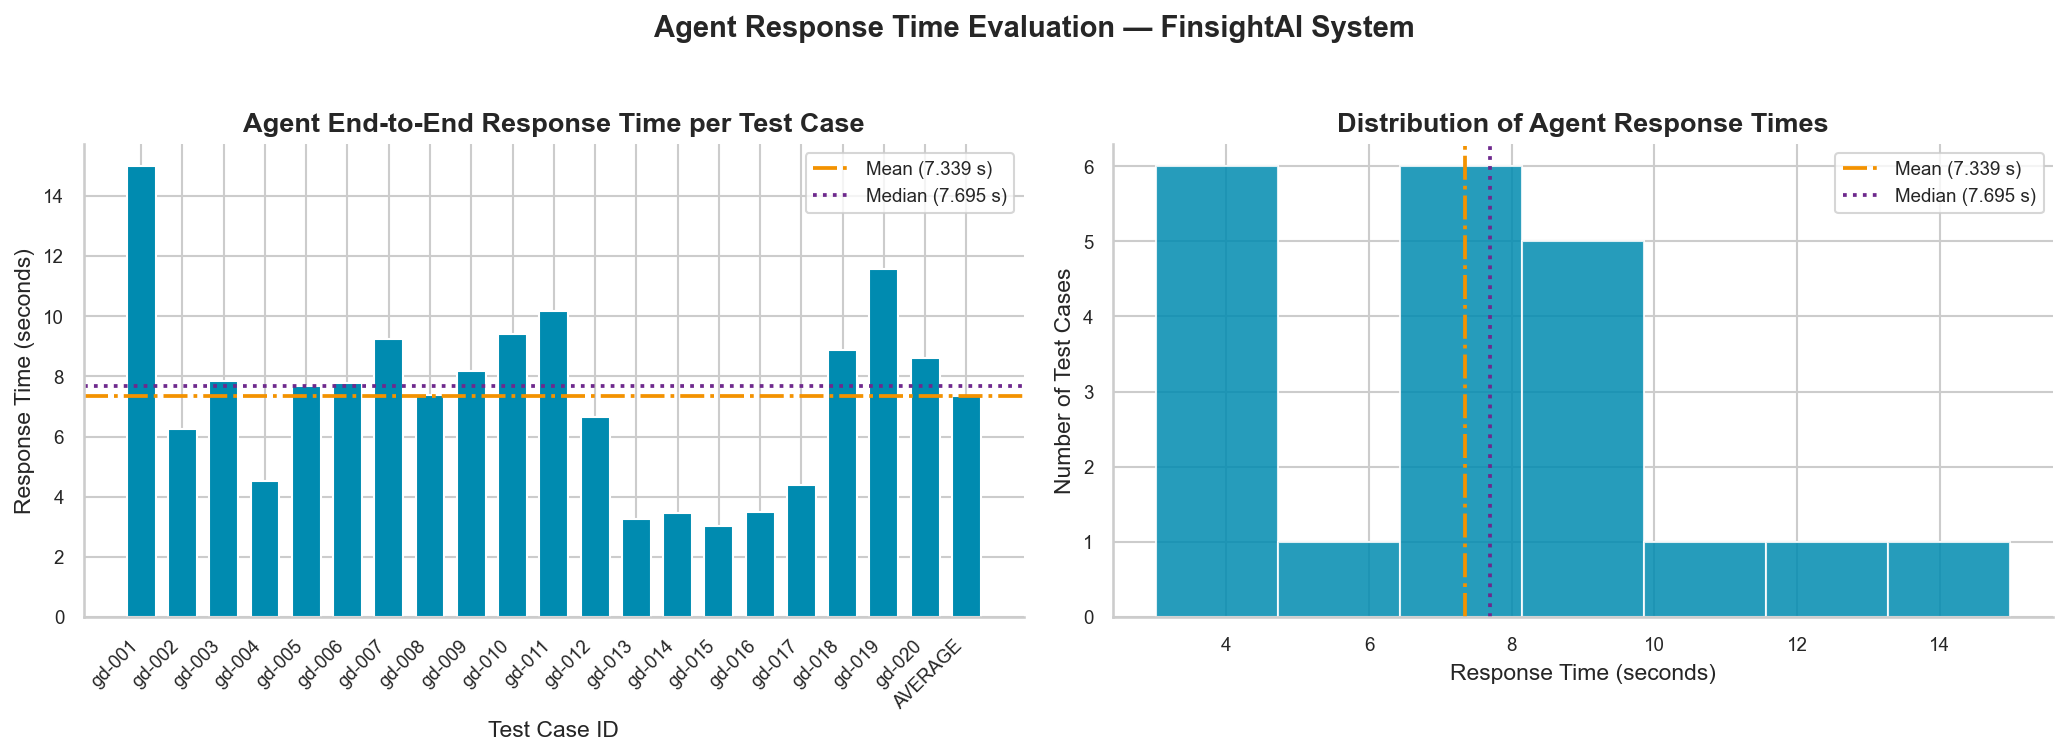

In [13]:
if "response_time" not in loaded:
    print("No response_time file found — skipping.")
else:
    rt = loaded["response_time"].copy()
    col = "response_time_s"
    if col not in rt.columns:
        print(f"Column '{col}' not found in response_time file. Columns: {rt.columns.tolist()}")
    else:
        avg_rt = rt[col].mean()
        med_rt  = rt[col].median()
        print(f"Average response time : {avg_rt:.3f} s")
        print(f"Median  response time : {med_rt:.3f} s")
        print(f"n = {len(rt)} cases")
        display(rt)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # --- Left: per-case bar ---
        ax = axes[0]
        ax.bar(range(len(rt)), rt[col], color=C_PRIMARY, width=0.7)
        if "id" in rt.columns:
            ax.set_xticks(range(len(rt)))
            ax.set_xticklabels(rt["id"], rotation=45, ha="right")
        ax.axhline(avg_rt, color=C_MEAN, linestyle="-.", linewidth=1.8,
                   label=f"Mean ({avg_rt:.3f} s)")
        ax.axhline(med_rt, color=C_ACCENT, linestyle=":", linewidth=1.8,
                   label=f"Median ({med_rt:.3f} s)")
        ax.set_title("Agent End-to-End Response Time per Test Case")
        ax.set_xlabel("Test Case ID")
        ax.set_ylabel("Response Time (seconds)")
        ax.legend()

        # --- Right: histogram ---
        ax = axes[1]
        ax.hist(rt[col], bins=max(5, len(rt) // 3), color=C_PRIMARY,
                edgecolor="white", alpha=0.85)
        ax.axvline(avg_rt, color=C_MEAN, linestyle="-.", linewidth=1.8,
                   label=f"Mean ({avg_rt:.3f} s)")
        ax.axvline(med_rt, color=C_ACCENT, linestyle=":", linewidth=1.8,
                   label=f"Median ({med_rt:.3f} s)")
        ax.set_title("Distribution of Agent Response Times")
        ax.set_xlabel("Response Time (seconds)")
        ax.set_ylabel("Number of Test Cases")
        ax.legend()

        fig.suptitle("Agent Response Time Evaluation — FinsightAI System", y=1.01)
        plt.tight_layout()
        plt.savefig("response_time_analysis.png", dpi=150, bbox_inches="tight")
        plt.show()

## 8  Overall Scorecard

In [ ]:
scorecard_rows = []


def _add(label, score, threshold):
    scorecard_rows.append({
        "Test": label,
        "Score": round(score, 4),
        "Threshold": threshold,
        "Gap": round(score - threshold, 4),
        "Status": "PASS" if score >= threshold else "FAIL",
    })


for emb_label, skey in similarity_result_iter():
    _add(f"Similarity pass-rate ({emb_label})", loaded[skey]["passed"].mean(), THRESHOLDS["similarity"])

for disp, hkey in hit_rate_result_iter():
    if "hit" in loaded[hkey].columns:
        _add(f"Hit rate — {disp}", loaded[hkey]["hit"].mean(), THRESHOLDS["hit_rate"])

for prefix, metric_col, threshold, label in RAGAS_TESTS:
    if prefix in loaded and metric_col in loaded[prefix].columns:
        _add(label, loaded[prefix][metric_col].mean(), threshold)

if "tool_call_accuracy" in loaded and "tool_call_accuracy" in loaded["tool_call_accuracy"].columns:
    _add("Tool Call Accuracy", loaded["tool_call_accuracy"]["tool_call_accuracy"].mean(), THRESHOLDS["tool_accuracy"])

if not scorecard_rows:
    print("No results to show yet.")
else:
    scorecard = pd.DataFrame(scorecard_rows)
    scorecard_styled = scorecard.style \
        .map(lambda v: "background-color: #c8f7c5" if v == "PASS" else "background-color: #f9c0c0",
                  subset=["Status"]) \
        .map(lambda v: "color: green" if v > 0 else "color: red", subset=["Gap"]) \
        .format({"Score": "{:.4f}", "Threshold": "{:.2f}", "Gap": "{:+.4f}"})
    display(scorecard_styled)


,Test,Score,Threshold,Gap,Status
0,Similarity pass-rate (Chroma),0.8750,0.50,+0.3750,PASS
1,Similarity pass-rate (OpenAI),1.0000,0.50,+0.5000,PASS
2,Hit rate — SEC – Chroma,0.9000,0.70,+0.2000,PASS
3,Hit rate — SEC – OpenAI,1.0000,0.70,+0.3000,PASS
4,Hit rate — News – Chroma,1.0000,0.70,+0.3000,PASS
5,Hit rate — News – OpenAI,1.0000,0.70,+0.3000,PASS
6,Faithfulness,0.4326,0.80,-0.3674,FAIL
7,Answer Relevancy,0.7333,0.80,-0.0667,FAIL
8,Tool Call Accuracy,0.9500,0.70,+0.2500,PASS


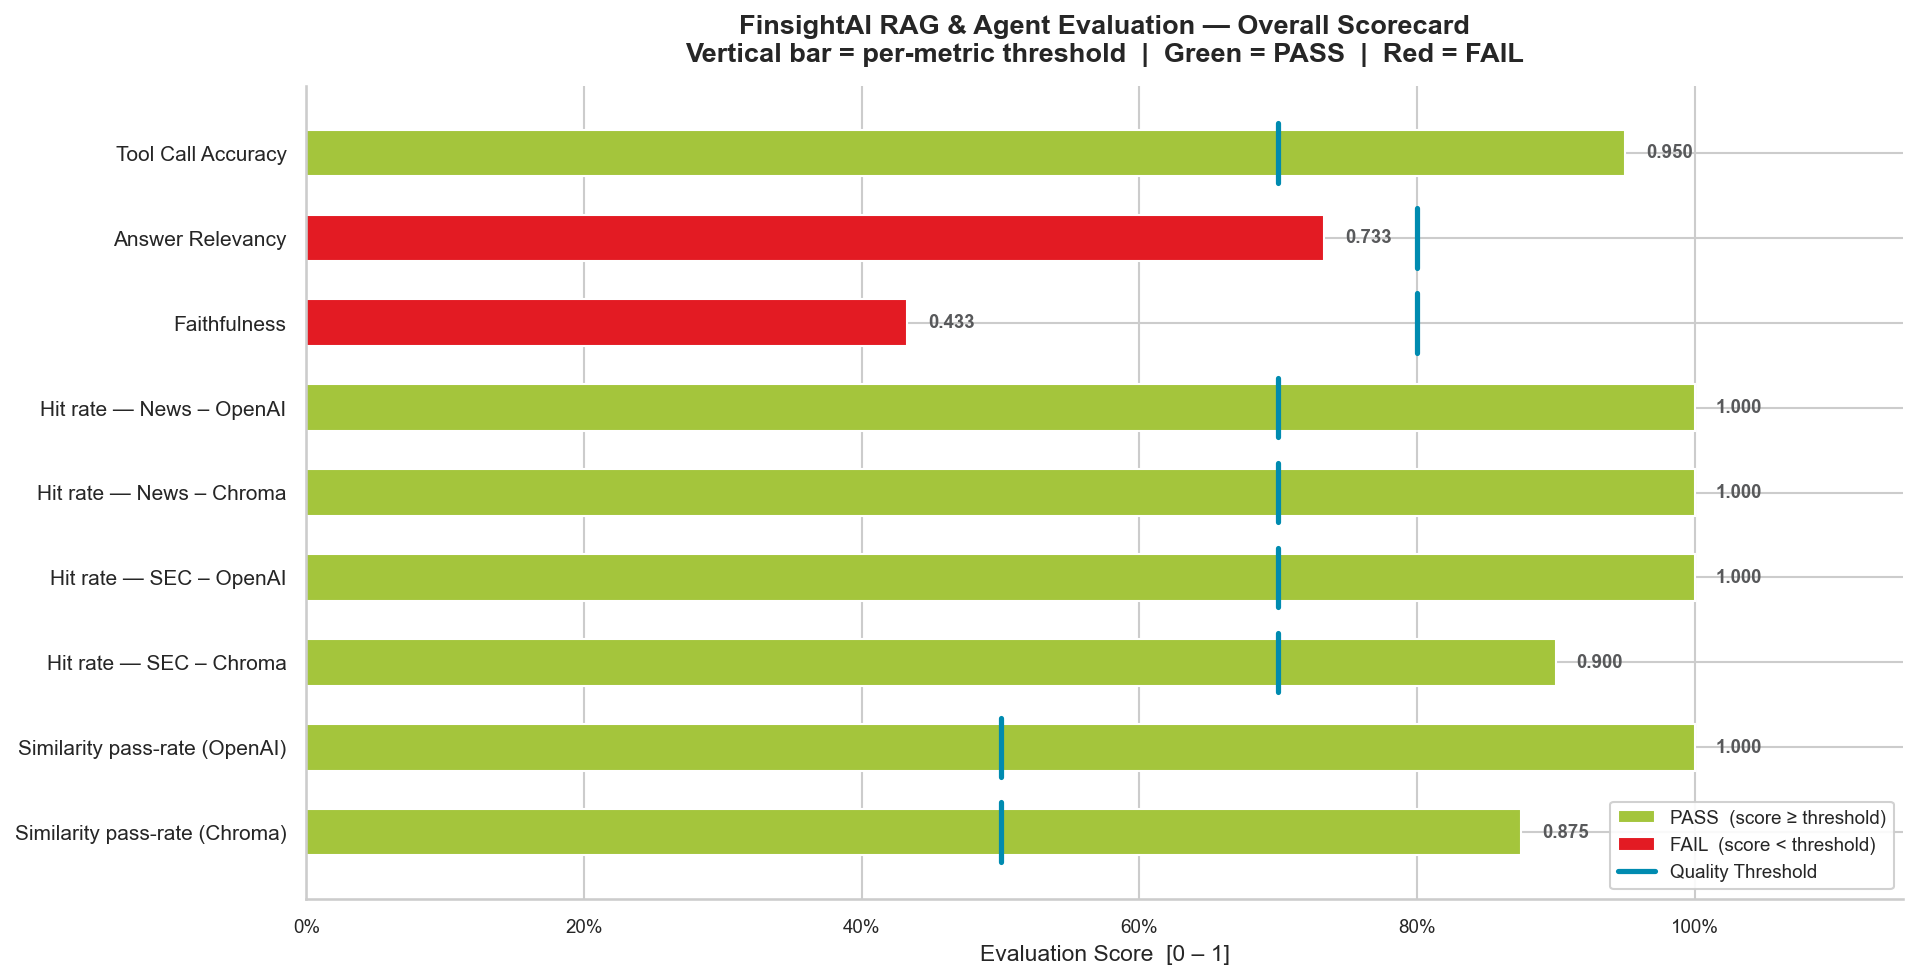

In [16]:
if scorecard_rows:
    scorecard = pd.DataFrame(scorecard_rows)

    fig, ax = plt.subplots(figsize=(13, max(4.5, len(scorecard) * 0.75)))

    y_pos = np.arange(len(scorecard))
    bar_colors = [C_PASS if s == "PASS" else C_FAIL for s in scorecard["Status"]]

    bars = ax.barh(y_pos, scorecard["Score"], color=bar_colors, height=0.55)

    # Draw per-metric threshold ticks
    for i, threshold in enumerate(scorecard["Threshold"]):
        ax.plot([threshold, threshold], [i - 0.35, i + 0.35],
                color=C_THRESHOLD, linewidth=2.5)

    # Score labels inside / outside bars
    for bar, score in zip(bars, scorecard["Score"]):
        ax.text(
            min(score + 0.015, 1.08),
            bar.get_y() + bar.get_height() / 2,
            f"{score:.3f}",
            va="center", ha="left", fontsize=9, fontweight="bold",
            color=UTS["grey"],
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(scorecard["Test"], fontsize=10)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("Evaluation Score  [0 – 1]", fontsize=11)
    ax.set_title(
        "FinsightAI RAG & Agent Evaluation — Overall Scorecard\n"
        "Vertical bar = per-metric threshold  |  Green = PASS  |  Red = FAIL",
        pad=12,
    )
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor=C_PASS,      label="PASS  (score ≥ threshold)"),
        Patch(facecolor=C_FAIL,      label="FAIL  (score < threshold)"),
        Line2D([0], [0], color=C_THRESHOLD, linewidth=2.5, label="Quality Threshold"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", framealpha=0.9)

    plt.tight_layout()
    plt.savefig("overall_scorecard.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9  Per-Question Deep Dive (Similarity Scores)

In [17]:
for emb_label, skey in similarity_result_iter():
    detail = loaded[skey].merge(
        golden[["id", "question", "expected_tool", "expected_collection", "ticker",
                "ground_truth", "expected_keywords"]],
        on="id", how="left"
    ).sort_values("similarity", ascending=False)

    detail["expected_keywords_str"] = detail["expected_keywords"].apply(
        lambda x: ", ".join(x) if isinstance(x, list) else str(x)
    )

    print(f"\n### Per-question detail — {emb_label} (`{skey}`)")
    display(
        detail[["id", "ticker", "similarity", "passed", "expected_collection",
                "question", "expected_keywords_str"]]
        .style
        .background_gradient(subset=["similarity"], cmap="RdYlGn", vmin=0, vmax=1)
        .map(lambda v: "background-color: #c8f7c5" if v else "background-color: #f9c0c0",
                  subset=["passed"])
        .format({"similarity": "{:.4f}"})
    )

    fails = detail[~detail["passed"]]
    if len(fails):
        print(f"\nFailing cases ({emb_label}, similarity < {THRESHOLDS['similarity']}):")
        display(fails[["id", "ticker", "similarity", "question", "expected_collection"]])
    else:
        print(f"\nNo failing cases for {emb_label}.")

if not list(similarity_result_iter()):
    print("No similarity files for deep dive.")



### Per-question detail — Chroma (`similarity_chroma`)


,id,ticker,similarity,passed,expected_collection,question,expected_keywords_str
14,gd-041,AMZN,0.7401,True,news,What recent news has affected Amazon's stock price?,"Amazon, AWS, advertising, Prime, stock, news"
9,gd-036,NVDA,0.6866,True,sec_filings,What does NVIDIA's 10-K disclose about export control risks?,"export, control, China, GPU, risk, H100"
12,gd-039,NVDA,0.6807,True,news,What is the latest news about NVIDIA's AI chip demand?,"NVIDIA, AI, chip, demand, GPU, data centre"
0,gd-001,AMZN,0.6517,True,sec_filings,What are Amazon's main risk factors according to the 10-K?,"competition, regulatory, cybersecurity, risk"
13,gd-040,MSFT,0.6449,True,news,What is the recent news sentiment around Microsoft and OpenAI?,"Microsoft, OpenAI, Copilot, AI, news"
2,gd-005,TSLA,0.6358,True,news,What recent news sentiment surrounds Tesla?,"Tesla, EV, delivery, FSD, news"
8,gd-035,TSLA,0.6327,True,sec_filings,What does Tesla's 10-K say about manufacturing risks?,"manufacturing, Gigafactory, supply chain, risk, battery"
10,gd-037,AAPL,0.6273,True,sec_filings,What are Apple's revenue recognition policies in its 10-K?,"revenue recognition, ASC 606, Apple, services, hardware"
7,gd-034,AMZN,0.6232,True,sec_filings,What does Amazon's 10-K say about AWS revenue growth?,"AWS, revenue, growth, cloud, segment"
4,gd-009,GOOGL,0.6223,True,sec_filings,What does Google's 10-K say about their AI strategy?,"AI, Gemini, Google, strategy, cloud"



Failing cases (Chroma, similarity < 0.5):


,id,ticker,similarity,question,expected_collection
5,gd-010,AAPL,0.477218,What are the recent news themes for Apple?,news
6,gd-012,NVDA,0.464510,Summarise NVDA's business model from its 10-K,sec_filings



### Per-question detail — OpenAI (`similarity_openai`)


,id,ticker,similarity,passed,expected_collection,question,expected_keywords_str
13,gd-040,MSFT,0.7078,True,news,What is the recent news sentiment around Microsoft and OpenAI?,"Microsoft, OpenAI, Copilot, AI, news"
9,gd-036,NVDA,0.6636,True,sec_filings,What does NVIDIA's 10-K disclose about export control risks?,"export, control, China, GPU, risk, H100"
2,gd-005,TSLA,0.6366,True,news,What recent news sentiment surrounds Tesla?,"Tesla, EV, delivery, FSD, news"
6,gd-012,NVDA,0.6359,True,sec_filings,Summarise NVDA's business model from its 10-K,"GPU, data centre, AI, gaming, NVIDIA"
4,gd-009,GOOGL,0.6357,True,sec_filings,What does Google's 10-K say about their AI strategy?,"AI, Gemini, Google, strategy, cloud"
0,gd-001,AMZN,0.6323,True,sec_filings,What are Amazon's main risk factors according to the 10-K?,"competition, regulatory, cybersecurity, risk"
3,gd-007,AMZN,0.6203,True,sec_filings,What capital expenditures did Amazon report in its 10-K?,"capex, capital expenditure, infrastructure, AWS"
14,gd-041,AMZN,0.6197,True,news,What recent news has affected Amazon's stock price?,"Amazon, AWS, advertising, Prime, stock, news"
1,gd-003,MSFT,0.6153,True,sec_filings,What are the key growth strategies mentioned in Microsoft's 10-K?,"Azure, cloud, AI, growth, Microsoft 365"
7,gd-034,AMZN,0.6152,True,sec_filings,What does Amazon's 10-K say about AWS revenue growth?,"AWS, revenue, growth, cloud, segment"



No failing cases for OpenAI.
